# Загрузка и первый взгляд на данные NBA Player Stats


Есть 2 датасета:

nba_players_2013_2026_full - статистика игроков за 2016-2026 годы

nba_teams_2013_2026_full - статистика команд за 2016-2026 годы

(датасеты были взяты с питоновской библиотеки - nba_api)

Загрузка данных с nba_api

In [2]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashteamstats

seasons = [
    '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21',
    '2021-22', '2022-23', '2023-24', '2024-25', '2025-26'
]

season_types = ['Regular Season', 'Playoffs']

player_stats_list = []
team_stats_list = []

for season in seasons:
    for s_type in season_types:
        print(f"Загрузка: {season} | Тип: {s_type}...")

        try:
            # 1. Загрузка статистики ИГРОКОВ
            player_info = leaguedashplayerstats.LeagueDashPlayerStats(
                season=season,
                per_mode_detailed='PerGame',
                season_type_all_star=s_type
            )
            df_players = player_info.get_data_frames()[0]
            df_players['SEASON'] = season
            df_players['SEASON_TYPE'] = s_type
            player_stats_list.append(df_players)

            time.sleep(1.2)

            team_info = leaguedashteamstats.LeagueDashTeamStats(
                season=season,
                per_mode_detailed='PerGame',
                season_type_all_star=s_type
            )
            df_teams = team_info.get_data_frames()[0]
            df_teams['SEASON'] = season
            df_teams['SEASON_TYPE'] = s_type
            team_stats_list.append(df_teams)

            time.sleep(1.2)

        except Exception as e:
            print(f"Ошибка в сезоне {season} ({s_type}): {e}")


all_players_df = pd.concat(player_stats_list, ignore_index=True)
all_teams_df = pd.concat(team_stats_list, ignore_index=True)

all_players_df.to_csv('nba_players_2013_2026_full.csv', index=False)
all_teams_df.to_csv('nba_teams_2013_2026_full.csv', index=False)

print("\nДанные успешно обновлены и разделены на Regular Season и Playoffs!")

Игроки: 9759 строк, 75 признаков
Команды: 582 строк, 57 признаков


### Ключевые столбцы статистики игроков

| Группа                  | Столбцы                                     | Описание                                                                    |
|-------------------------|---------------------------------------------|-----------------------------------------------------------------------------|
| Идентификаторы          | `PLAYER_NAME`, `TEAM_ID`, `TEAM_ABBREVIATION`, `SEASON` | Имя игрока, команда, сезон, id команды                                                |
| Метаданные              | `SEASON_TYPE`, `AGE`, `GP`, `MIN`           | Тип игр (Regular Season/Playoffs), возраст, сыгранные матчи, минуты за игру |
| Бросковая эффективность | `FG_PCT`, `FG3_PCT`, `FT_PCT`      | Общий процент попаданий, 3-очковый процент, процент со штрафных             |
| Ранкинг                 | `PTS_RANK`, `AST_RANK`, `REB_RANK`  | Ранкинг очков, подборов, передач итд                                        |
| Базовая статистика      | `PTS`, `REB`, `AST`, `STL`, `BLK`, `TOV`    | Очки, подборы, передачи, перехваты, блок-шоты, потери в среднем за игру     |

### Ключевые столбцы статистики команд

| Группа             | Столбцы                                  | Описание                                                                                        |
|--------------------|------------------------------------------|-------------------------------------------------------------------------------------------------|
| Идентификаторы     | `TEAM_NAME`, `TEAM_ID`, `SEASON`         | Имя команды, id команды, сезон                                                                  |
| Метаданные         | `SEASON_TYPE`, `GP`, `W`, `L`, `MIN`     | Тип игр (Regular Season/Playoffs), возраст, сыгранные матчи, минуты за игру, победы и поражения |
| Эффективность      | `FG_PCT`, `FG_PCT`, `FG3_PCT`, `FT_PCT`  | Процент побед, общий процент попаданий, 3-очковый процент, процент со штрафных                  |
| Ранкинг            | `PTS_RANK`, `AST_RANK`, `REB_RANK`       | Ранкинг очков, подборов, передач итд                                                            |
| Базовая статистика | `PTS`, `REB`, `AST`, `STL`, `BLK`, `TOV` | Очки, подборы, передачи, перехваты, блок-шоты, потери в среднем за игру                         |

#### Загрузка данных и дополнеение их необходимыми в дальнейшем столбцами

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_players = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_players_2013_2026_full.csv')
df_teams = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_teams_2013_2026_full.csv')

df_players['TS_PCT'] = df_players['PTS'] / (2 * (df_players['FGA'] + 0.44 * df_players['FTA']))
df_players['TS_PCT'] = df_players['TS_PCT'].replace([np.inf, -np.inf], np.nan).fillna(0)

#mvp, mip, dpoy, roy, nba camp

mvp_winners = {
    "2013-14": "Kevin Durant",
    "2014-15": "Stephen Curry", "2015-16": "Stephen Curry",
    "2016-17": "Russell Westbrook", "2017-18": "James Harden",
    "2018-19": "Giannis Antetokounmpo", "2019-20": "Giannis Antetokounmpo",
    "2020-21": "Nikola Jokic", "2021-22": "Nikola Jokić",
    "2022-23": "Joel Embiid", "2023-24": "Nikola Jokić",
    "2024-25": "Nikola Jokić", "2025-26": "Shai Gilgeous-Alexander"
}

dpoy_winners = {
    "2013-14": "Joakim Noah",
    "2014-15": "Kawhi Leonard", "2015-16": "Kawhi Leonard",
    "2016-17": "Draymond Green", "2017-18": "Rudy Gobert",
    "2018-19": "Rudy Gobert", "2019-20": "Giannis Antetokounmpo",
    "2020-21": "Rudy Gobert", "2021-22": "Marcus Smart",
    "2022-23": "Jaren Jackson Jr.", "2023-24": "Rudy Gobert",
    "2024-25": "Evan Mobley", "2025-26": "Victor Wembanyama"
}

mip_winners = {
    "2013-14": "Goran Dragić",
    "2014-15": "Jimmy Butler", "2015-16": "CJ McCollum",
    "2016-17": "Giannis Antetokounmpo", "2017-18": "Victor Oladipo",
    "2018-19": "Pascal Siakam", "2019-20": "Brandon Ingram",
    "2020-21": "Julius Randle", "2021-22": "Ja Morant",
    "2022-23": "Lauri Markkanen", "2023-24": "Tyrese Maxey",
    "2024-25": "Dyson Daniels", "2025-26": "Nickeil Alexander-Walker"
}

roty_winners = {
    "2013-14": "Michael Carter-Williams",
    "2014-15": "Andrew Wiggins", "2015-16": "Karl-Anthony Towns",
    "2016-17": "Malcolm Brogdon", "2017-18": "Ben Simmons",
    "2018-19": "Luka Doncic", "2019-20": "Ja Morant",
    "2020-21": "LaMelo Ball", "2021-22": "Scottie Barnes",
    "2022-23": "Paolo Banchero", "2023-24": "Victor Wembanyama",
    "2024-25": "Stephon Castle"
}

champions_teams = {
    "2013-14": "San Antonio Spurs",
    "2014-15": "Golden State Warriors", "2015-16": "James Harden",
    "2016-17": "Golden State Warriors", "2017-18": "Cleveland Cavaliers",
    "2018-19": "Toronto Raptors", "2019-20": "Los Angeles Lakers",
    "2020-21": "Milwaukee Bucks", "2021-22": "Golden State Warriors",
    "2022-23": "Denver Nuggets", "2023-24": "Boston Celtics",
    "2024-25": "Oklahoma City Thunder"
}

def label_awards(df, winners_dict, col_name):
    df[col_name] = df.apply(lambda x: 1 if winners_dict.get(x['SEASON']) == x['PLAYER_NAME'] else 0, axis=1)
    return df

df_players = label_awards(df_players, mvp_winners, 'IS_MVP')
df_players = label_awards(df_players, dpoy_winners, 'IS_DPOY')
df_players = label_awards(df_players, mip_winners, 'IS_MIP')
df_players = label_awards(df_players, roty_winners, 'IS_ROTY')


df_teams['IS_CHAMPION'] = df_teams.apply(
    lambda x: 1 if champions_teams.get(x['SEASON']) == x['TEAM_NAME'] else 0, axis=1
)

#usg
players = df_players.copy()
teams = df_teams.copy()

team_cols = ['TEAM_ID', 'SEASON', 'SEASON_TYPE', 'MIN', 'FGA', 'FTA', 'TOV']
teams_subset = teams[team_cols].copy()
teams_subset.columns = ['TEAM_ID', 'SEASON', 'SEASON_TYPE', 'Tm_MIN', 'Tm_FGA', 'Tm_FTA', 'Tm_TOV']

df_analysis = players.merge(teams_subset, on=['TEAM_ID', 'SEASON', 'SEASON_TYPE'], how='left')

df_players['USG_PCT'] = 100 * (
    (df_analysis['FGA'] + 0.44 * df_analysis['FTA'] + df_analysis['TOV']) * (df_analysis['Tm_MIN'])
) / (
    df_analysis['MIN'] * (df_analysis['Tm_FGA'] + 0.44 * df_analysis['Tm_FTA'] + df_analysis['Tm_TOV'])
)

df_players_reg = df_players[df_players['SEASON_TYPE'] == 'Regular Season'].copy()
df_teams_reg = df_teams[df_teams['SEASON_TYPE'] == 'Regular Season'].copy()

df_players_po = df_players[df_players['SEASON_TYPE'] == 'Playoffs'].copy()
df_teams_po = df_teams[df_teams['SEASON_TYPE'] == 'Playoffs'].copy()

print(f"Игроки: {df_players.shape[0]} строк, {df_players.shape[1]} признаков")
print(f"Команды: {df_teams.shape[0]} строк, {df_teams.shape[1]} признаков")

Игроки: 9759 строк, 75 признаков
Команды: 582 строк, 57 признаков


In [3]:
display(df_teams.head(3))

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SEASON,SEASON_TYPE,IS_CHAMPION
0,1610612737,Atlanta Hawks,82,38,44,0.463,48.4,37.3,81.6,0.458,...,9,26,12,7,20,15,17,2013-14,Regular Season,0
1,1610612738,Boston Celtics,82,25,57,0.305,48.1,36.5,83.9,0.435,...,23,23,13,19,28,26,25,2013-14,Regular Season,0
2,1610612751,Brooklyn Nets,82,44,38,0.537,48.5,35.7,77.9,0.459,...,4,28,9,21,11,21,19,2013-14,Regular Season,0


In [4]:
display(df_players.head(3))

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON,SEASON_TYPE,TS_PCT,IS_MVP,IS_DPOY,IS_MIP,IS_ROTY,USG_PCT
0,201985,AJ Price,AJ,1610612750,MIN,27.0,28,15,13,0.536,...,462,1,2013-14,Regular Season,0.486618,0,0,0,0,23.630272
1,201166,Aaron Brooks,Aaron,1610612743,DEN,29.0,72,42,30,0.583,...,191,2,2013-14,Regular Season,0.518911,0,0,0,0,20.218200
2,201189,Aaron Gray,Aaron,1610612758,SAC,29.0,37,12,25,0.324,...,393,2,2013-14,Regular Season,0.494505,0,0,0,0,12.039856


In [5]:
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9759 entries, 0 to 9758
Data columns (total 75 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              9759 non-null   int64  
 1   PLAYER_NAME            9759 non-null   object 
 2   NICKNAME               9759 non-null   object 
 3   TEAM_ID                9759 non-null   int64  
 4   TEAM_ABBREVIATION      9759 non-null   object 
 5   AGE                    9759 non-null   float64
 6   GP                     9759 non-null   int64  
 7   W                      9759 non-null   int64  
 8   L                      9759 non-null   int64  
 9   W_PCT                  9759 non-null   float64
 10  MIN                    9759 non-null   float64
 11  FGM                    9759 non-null   float64
 12  FGA                    9759 non-null   float64
 13  FG_PCT                 9759 non-null   float64
 14  FG3M                   9759 non-null   float64
 15  FG3A

In [6]:
df_teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TEAM_ID          582 non-null    int64  
 1   TEAM_NAME        582 non-null    object 
 2   GP               582 non-null    int64  
 3   W                582 non-null    int64  
 4   L                582 non-null    int64  
 5   W_PCT            582 non-null    float64
 6   MIN              582 non-null    float64
 7   FGM              582 non-null    float64
 8   FGA              582 non-null    float64
 9   FG_PCT           582 non-null    float64
 10  FG3M             582 non-null    float64
 11  FG3A             582 non-null    float64
 12  FG3_PCT          582 non-null    float64
 13  FTM              582 non-null    float64
 14  FTA              582 non-null    float64
 15  FT_PCT           582 non-null    float64
 16  OREB             582 non-null    float64
 17  DREB            

Почистим данные от игроков, которые сыграли меньше 5 игр и 5 минут за игру(так как достаточно часто в регулярном чемпионате возникают ситуации в концовке когда результат предрешен и на корт выходят игроки 3-го эшелона, это мусорное время, также в нба существуют 10-дневные контракты)

In [7]:
df_players_clean = df_players[(df_players['GP'] >= 5) & (df_players['MIN'] >= 5)].copy()
df_players_reg_clean = df_players_reg[(df_players_reg['GP'] >= 5) & (df_players_reg['MIN'] >= 5)].copy()

perc_cols = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'TS_PCT']
df_players_clean[perc_cols] = df_players_clean[perc_cols].fillna(0)

print(f"Игроков после фильтрации: {len(df_players_clean)}")
print(f"Игроков reg после фильтрации: {len(df_players_reg_clean)}")

Игроков после фильтрации: 8119
Игроков reg после фильтрации: 6297


## Подготовка данных по игрокам


#### Распределение данных


Гистограммы показывают усредненные значения по лиге

Так например для очков за игру большинство игроков набирает 5-10 очков но также есть суперзвезды, которые показывают запредельную результативность, но в плей-офф график смещается влево относительно регулярки

Возрастное распределение демонстрирует пик игровой формы для большинства игроков и он примерно одинаков для плей-офф и регулярки

Распределение по минутам за игру показывает ротацию
В регулярном чемпионате распределение находится в районе от 5 до 36 минут и у 40 минут за игру оно резко падает, в плей-офф же рапределение около 40 минут примерно такое же как и 20 и 30 минут

Потери в плей-офф в среднем сокращаются

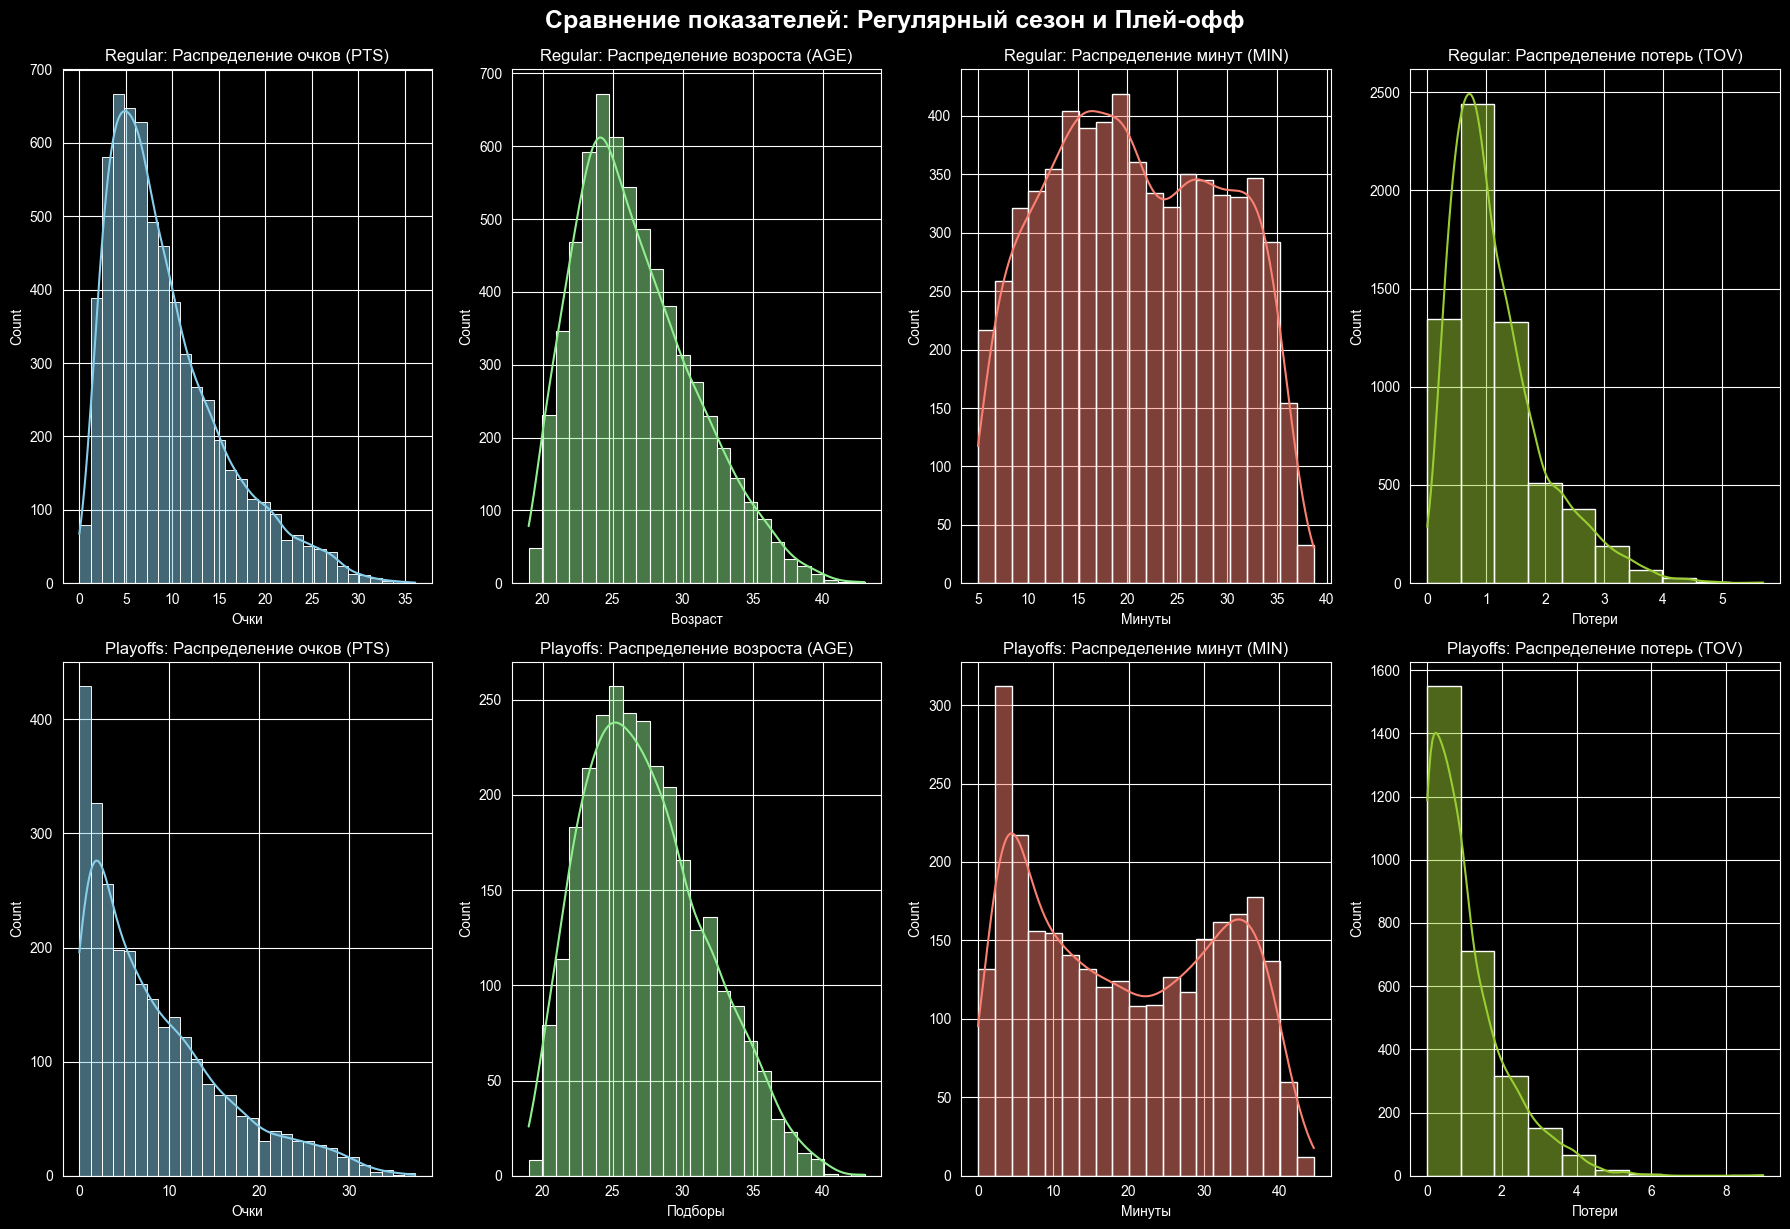

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

sns.histplot(df_players_reg_clean['PTS'], kde=True, bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Regular: Распределение очков (PTS)')
axes[0, 0].set_xlabel('Очки')

sns.histplot(df_players_reg_clean['AGE'], kde=True, bins=25, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Regular: Распределение возроста (AGE)')
axes[0, 1].set_xlabel('Возраст')

sns.histplot(df_players_reg_clean['MIN'], kde=True, bins=20, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Regular: Распределение минут (MIN)')
axes[0, 2].set_xlabel('Минуты')

sns.histplot(df_players_reg_clean['TOV'], kde=True, bins=10, ax=axes[0, 3], color='yellowgreen')
axes[0, 3].set_title('Regular: Распределение потерь (TOV)')
axes[0, 3].set_xlabel('Потери')

sns.histplot(df_players_po['PTS'], kde=True, bins=30, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Playoffs: Распределение очков (PTS)')
axes[1, 0].set_xlabel('Очки')

sns.histplot(df_players_po['AGE'], kde=True, bins=25, ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Playoffs: Распределение возроста (AGE)')
axes[1, 1].set_xlabel('Подборы')

sns.histplot(df_players_po['MIN'], kde=True, bins=20, ax=axes[1, 2], color='salmon')
axes[1, 2].set_title('Playoffs: Распределение минут (MIN)')
axes[1, 2].set_xlabel('Минуты')

sns.histplot(df_players_po['TOV'], kde=True, bins=10, ax=axes[1, 3], color='yellowgreen')
axes[1, 3].set_title('Playoffs: Распределение потерь (TOV)')
axes[1, 3].set_xlabel('Потери')

plt.tight_layout()
plt.suptitle('Сравнение показателей: Регулярный сезон и Плей-офф', y=1.02, fontsize=18, fontweight='bold')
plt.show()


#### Выбросы


Боксплоты средние значения по лиге по основным показателям

Выбросы - звезды в этих показателях

Больше всего выбросов в очках, а меньше всего в перехватах и блокшотах(так как в любой команде есть скорер и это не требует черезмерных таллантов, но вот перехваты и блокшоты это совершено другое, здесь игрок должен обладать особыми умениями в защите, и таковых в лиге мало)

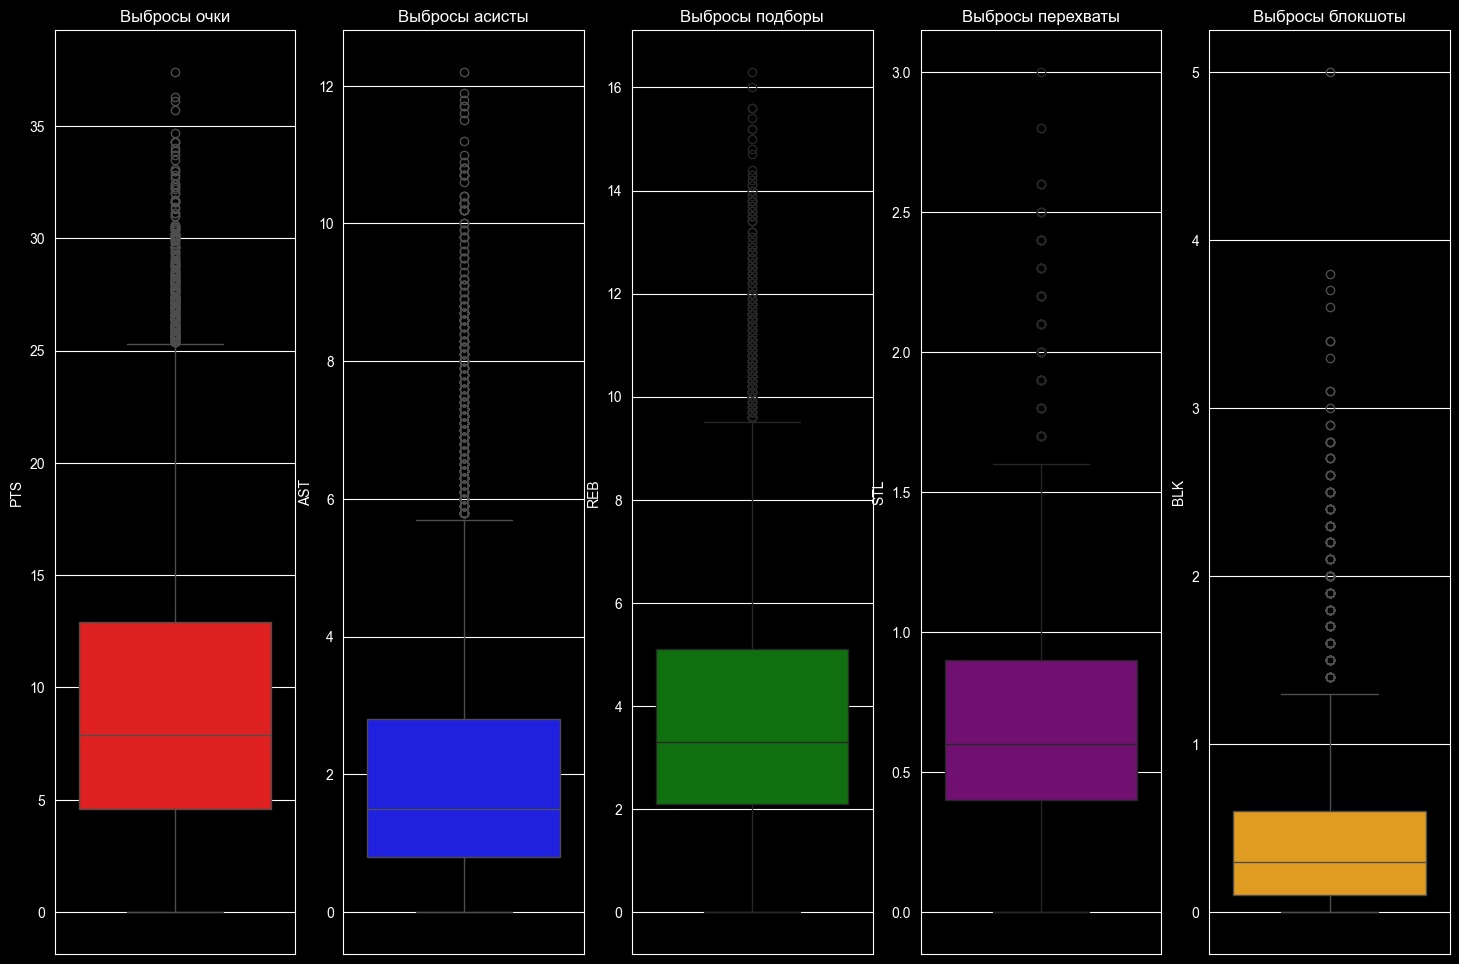

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 12))

sns.boxplot(data=df_players_clean['PTS'], ax=axes[0], color="red")
axes[0].set_title('Выбросы очки')

sns.boxplot(data=df_players_clean['AST'], ax=axes[1], color="blue")
axes[1].set_title('Выбросы асисты')

sns.boxplot(data=df_players_clean['REB'], ax=axes[2], color="green")
axes[2].set_title('Выбросы подборы')

sns.boxplot(data=df_players_clean['STL'], ax=axes[3], color="purple")
axes[3].set_title('Выбросы перехваты')

sns.boxplot(data=df_players_clean['BLK'], ax=axes[4], color="orange")
axes[4].set_title('Выбросы блокшоты')

plt.show()

#### Корреляционная матрица

TOV(потери за матч) коррелируют с количеством очков, минут и асистами за матч, что логично(больше пользы от игрока в атаке = лучше против него защищаются)

Не такой очевидной являются корреляция между очками и асистами(это может происходить из-за сдваивания на игроке набирающем хорошие очки, следовательно появляются открытые тиммейты)

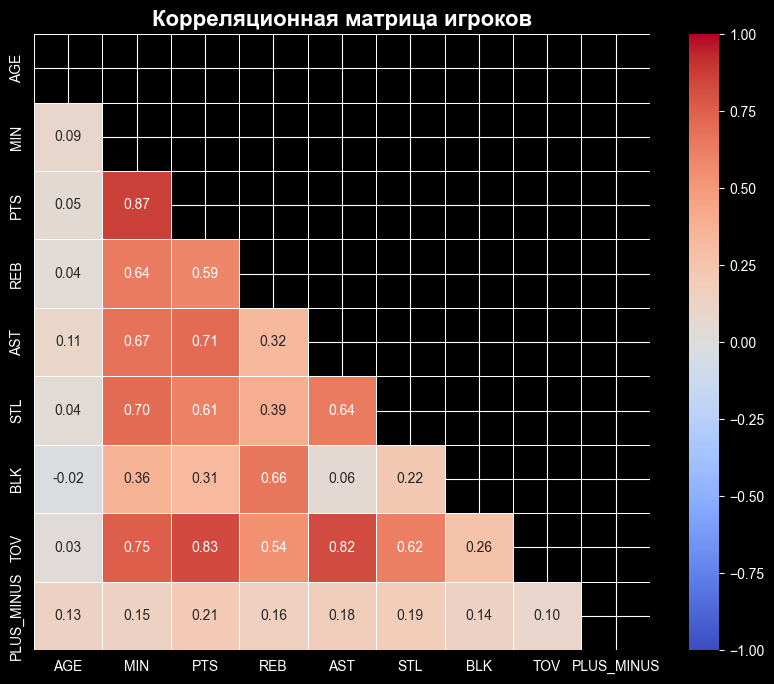

In [10]:
cols_for_corr = ['AGE', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS']
corr_matrix = df_players_clean[cols_for_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Корреляционная матрица игроков', fontsize=16, fontweight='bold')
plt.show()

#### Тру шутинг и задействование

График показывает разделение игроков на типы

1) правый верхний угол - суперзвезды, которые имеют большое задействование, и при этом они завершают атаки с высокой точностью
2) правый нижний - мусорные скороры(много на себя берут и плохо реализуют)
3) левый верхний - качественные ролевики(мало берут на себя с хорошей реализацией)

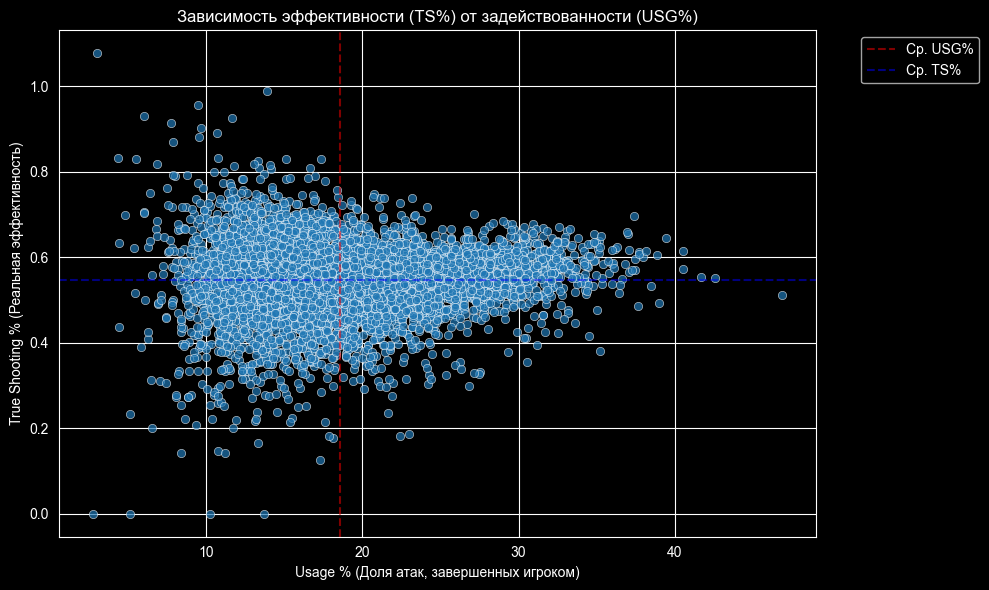

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_players_clean, x='USG_PCT', y='TS_PCT', alpha=0.7, color='tab:blue')

plt.axvline(x=df_players_clean['USG_PCT'].mean(), color='red', linestyle='--', alpha=0.5, label='Ср. USG%')
plt.axhline(y=df_players_clean['TS_PCT'].mean(), color='blue', linestyle='--', alpha=0.5, label='Ср. TS%')

plt.title('Зависимость эффективности (TS%) от задействованности (USG%)')
plt.xlabel('Usage % (Доля атак, завершенных игроком)')
plt.ylabel('True Shooting % (Реальная эффективность)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Процент реализации к попыткам с учетом плюс-минуса

Данная графика показывает, что даже при хорошей реализации на больших попытках игрок может вредить команде(с ним на площадке команда больше пропускает, чем забивает)

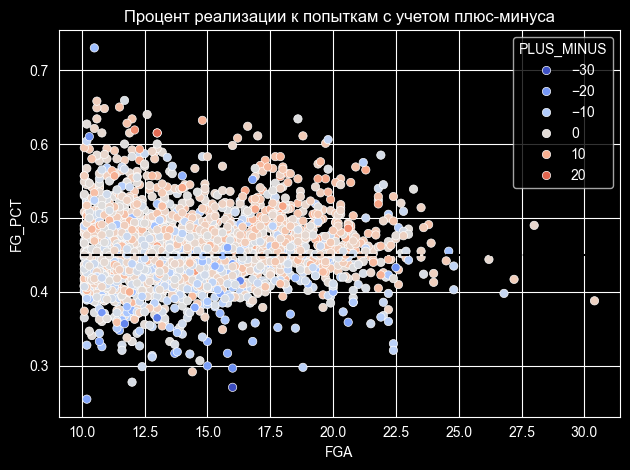

In [18]:
sns.scatterplot(data=df_players[df_players['FGA'] > 10], x='FGA', y='FG_PCT', hue='PLUS_MINUS', palette='coolwarm')
plt.axhline(0.45, color='black', linestyle='--')
plt.title('Процент реализации к попыткам с учетом плюс-минуса')
plt.tight_layout()
plt.show()

## Подготовка данных по командам

#### Распределение данных


Распределение данных показывает, что в среднем процент побед - 50%

Но процент побед смещен от центра, так как есть контендеры(команды которые борятся за титул) и такнкующие команды(они сливают сезон ради хорошего пика на драфте)


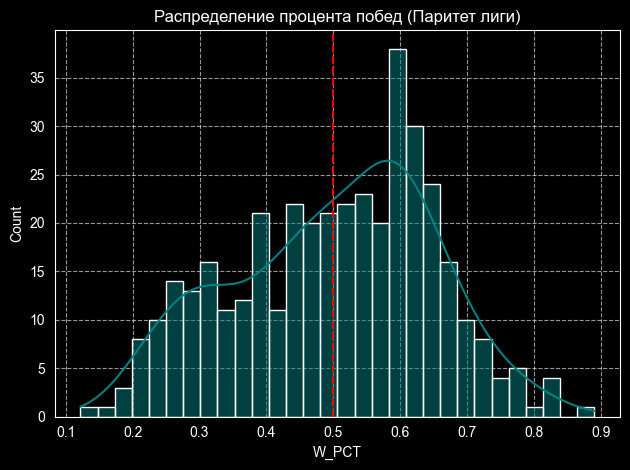

In [19]:
sns.histplot(df_teams_reg['W_PCT'], bins=30, kde=True, color='teal')
plt.axvline(0.5, color='red', linestyle='--')
plt.title('Распределение процента побед (Паритет лиги)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Результативность по годам

Мы видим, что с каждым годом кол-во очков команд в среднем за матч смещается в верх, а количество попыток в право

Это говорит о том, что темп в лиге увеличивается(время, которое команда тратит на атаку уменьшается)


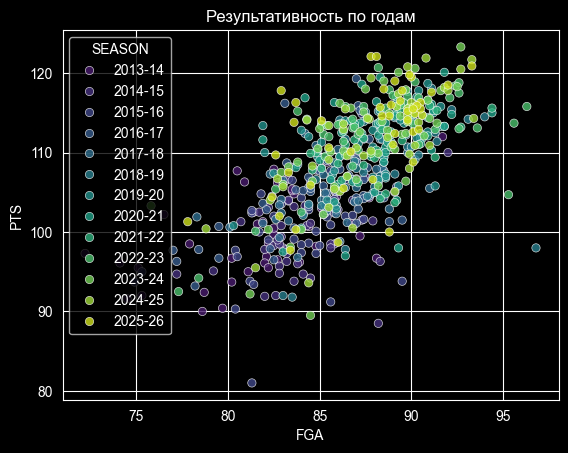

In [14]:
sns.scatterplot(data=df_teams, x='FGA', y='PTS', hue='SEASON', palette='viridis', alpha=0.8)
plt.title('Результативность по годам')
plt.show()

#### Значимость скоринга франчайза в регулярке и плей-офф


Как можно заметить влияние количества забитых очков главной звездой уменьшается в плей-офф


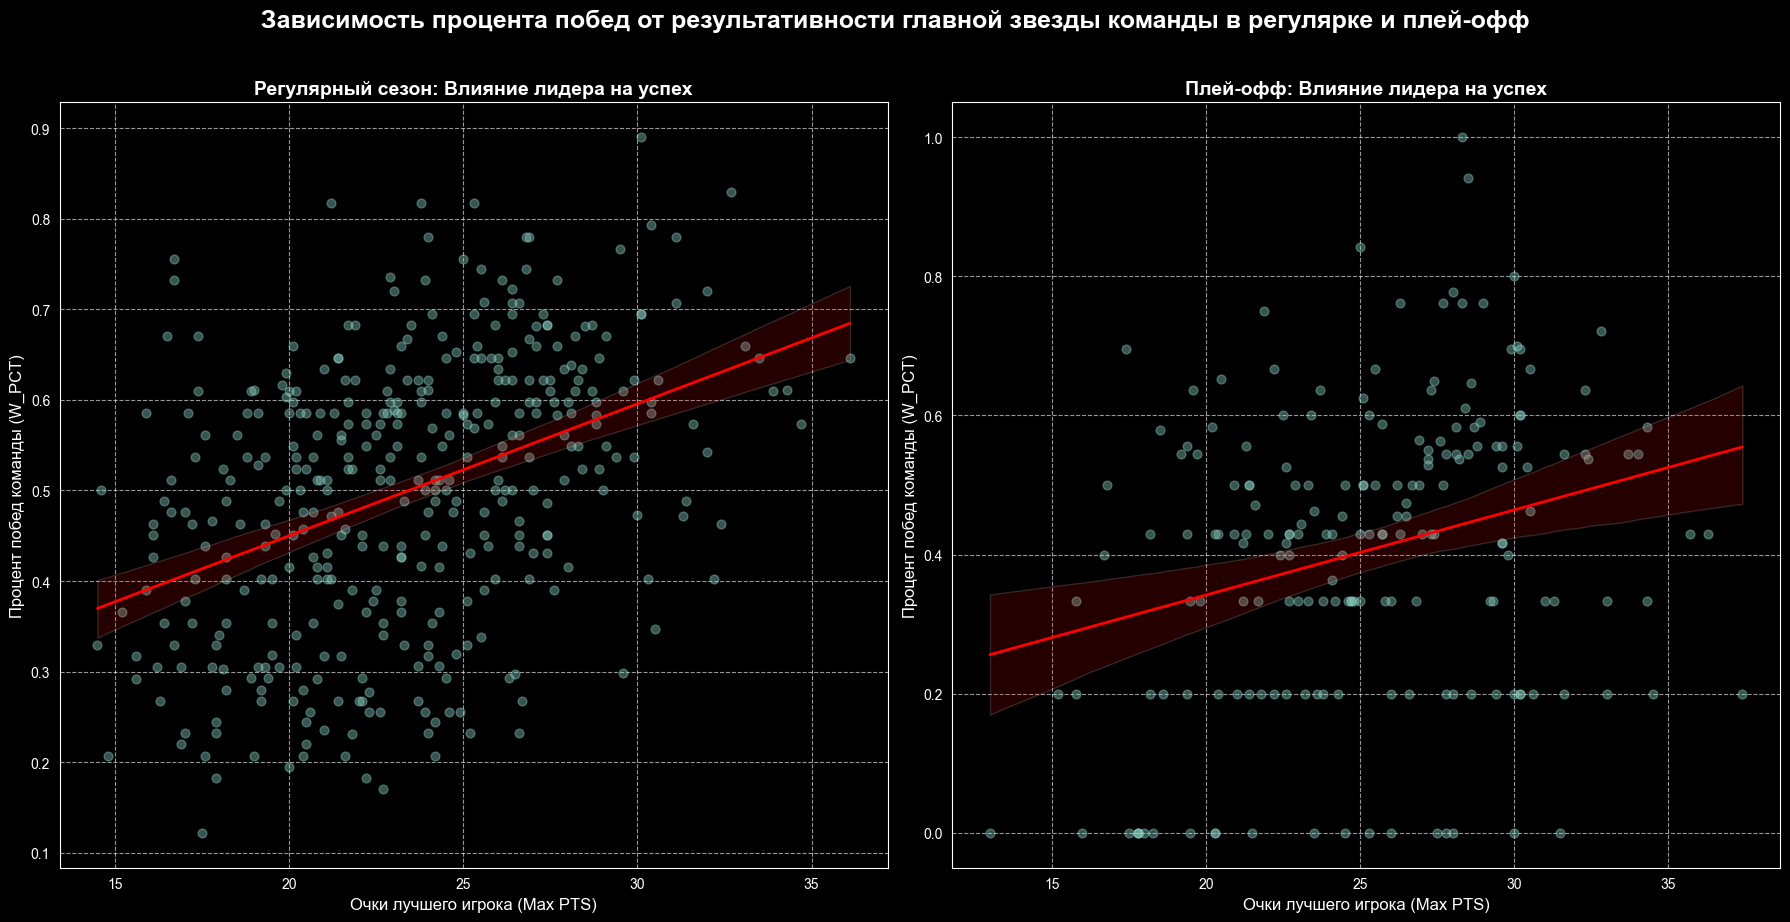

In [20]:
top_scorers_reg = df_players_reg.groupby(['TEAM_ID', 'SEASON'])['PTS'].max().reset_index()
merged_reg = pd.merge(top_scorers_reg, df_teams_reg[['TEAM_ID', 'SEASON', 'W_PCT', 'TEAM_NAME']], on=['TEAM_ID', 'SEASON'])

top_scorers_po = df_players_po.groupby(['TEAM_ID', 'SEASON'])['PTS'].max().reset_index()
merged_po = pd.merge(top_scorers_po, df_teams_po[['TEAM_ID', 'SEASON', 'W_PCT', 'TEAM_NAME']], on=['TEAM_ID', 'SEASON'])

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

sns.regplot(data=merged_reg, x='PTS', y='W_PCT', scatter_kws={'alpha':0.4, 's':40}, line_kws={'color':'red', 'lw':2}, ax=axes[0])
axes[0].set_title('Регулярный сезон: Влияние лидера на успех', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Очки лучшего игрока (Max PTS)', fontsize=12)
axes[0].set_ylabel('Процент побед команды (W_PCT)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.regplot(data=merged_po, x='PTS', y='W_PCT', scatter_kws={'alpha':0.4, 's':40}, line_kws={'color':'red', 'lw':2}, ax=axes[1])
axes[1].set_title('Плей-офф: Влияние лидера на успех', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Очки лучшего игрока (Max PTS)', fontsize=12)
axes[1].set_ylabel('Процент побед команды (W_PCT)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Зависимость процента побед от результативности главной звезды команды в регулярке и плей-офф', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### Стабильность франшиз


График полностью отражает стабильность каждой из команд в лиге за последние 10 лет

Так например:

Лос Анджелес Лейкерс - самые стабильные по регулярному сезону, но при этом у них всего 1 чемпионство за последние 10 лет

Также можно сказать, что ни одна команда из правой части не становилась чемпионом за последние 10 лет


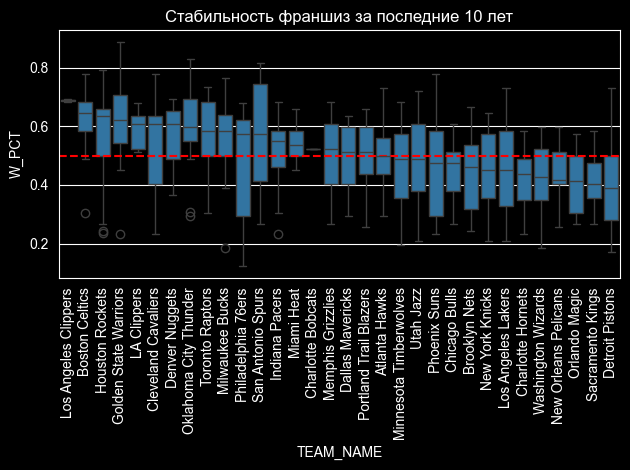

In [21]:
order = df_teams_reg.groupby('TEAM_NAME')['W_PCT'].median().sort_values(ascending=False).index
sns.boxplot(data=df_teams_reg, x='TEAM_NAME', y='W_PCT', order=order, color='tab:blue')
plt.tick_params(axis='x', rotation=90)
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Стабильность франшиз за последние 10 лет')
plt.tight_layout()
plt.show()

#### Баскебольная революция


График показывает революцию, направленую на рост количества 3-очковых бросков в баскеболе

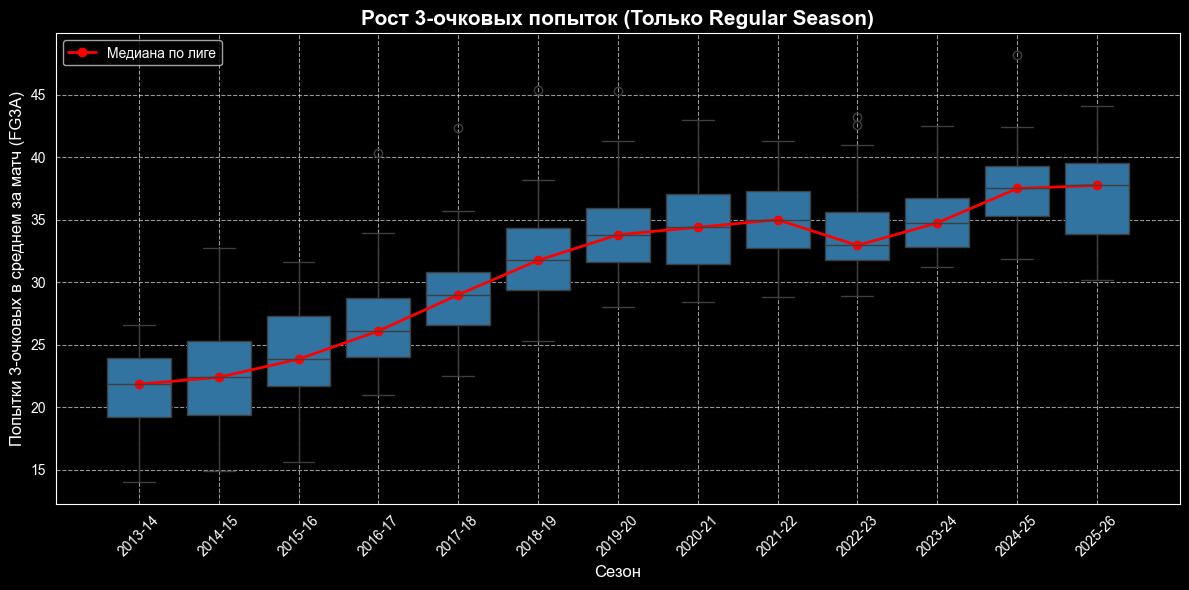

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_teams_reg, x='SEASON', y='FG3A', color='tab:blue')

plt.title('Рост 3-очковых попыток (Только Regular Season)', fontsize=15, fontweight='bold')
plt.xlabel('Сезон', fontsize=12)
plt.ylabel('Попытки 3-очковых в среднем за матч (FG3A)', fontsize=12)
plt.xticks(rotation=45)

medians = df_teams_reg.groupby('SEASON')['FG3A'].median().values

plt.plot(range(len(medians)), medians, color='red', marker='o', linestyle='-', linewidth=2, label='Медиана по лиге')

plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Задачи, модели и метрики

#### Задача:

1)Предсказать победителя NBA

2)Предсказание по 4 индивидуальным наградам: MVP, MIP, DPOY, ROTY

#### Выбранные модели:

Logistic Regression

Random Forest

XGBoost (Extreme Gradient Boosting)

#### Метрики качества:

Precision

AUC

# Прогнозирование Чемпиона и Индивидуальных наград NBA

### Шаг 1: Загрузка библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, roc_curve, accuracy_score, log_loss, brier_score_loss, make_scorer
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

plt.rcParams['figure.figsize'] = (10, 6)


### Шаг 2: Загрузка датасетов и добавление новых параметров

In [9]:
df_players = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_players_2013_2026_full.csv')
df_teams = pd.read_csv('/Users/ivankuznecov/Desktop/статпрак/nba_teams_2013_2026_full.csv')

df_players = df_players[df_players['SEASON_TYPE'] == 'Regular Season'].copy()
df_teams = df_teams[df_teams['SEASON_TYPE'] == 'Regular Season'].copy()

df_players['TS_PCT'] = df_players['PTS'] / (2 * (df_players['FGA'] + 0.44 * df_players['FTA']))
df_players['TS_PCT'] = df_players['TS_PCT'].replace([np.inf, -np.inf], np.nan).fillna(0)

def apply_season_rank(df, cols):
    for col in cols:
        df[f'{col}_RANK'] = df.groupby('SEASON')[col].rank(pct=True)
    return df

player_stats = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'W_PCT', 'PLUS_MINUS', 'TS_PCT']
team_stats = ['W_PCT', 'PLUS_MINUS', 'PTS', 'REB', 'AST', 'FG_PCT']

df_players = apply_season_rank(df_players, player_stats)
df_teams = apply_season_rank(df_teams, team_stats)

df_players = df_players.sort_values(['PLAYER_ID', 'SEASON'])
for stat in ['PTS', 'AST', 'REB', 'STL', 'BLK', 'NBA_FANTASY_PTS', 'MIN']:
    df_players[f'DELTA_{stat}'] = df_players.groupby('PLAYER_ID')[stat].diff().fillna(0)

first_seasons = df_players.groupby('PLAYER_ID')['SEASON'].transform('min')
df_players['IS_ROOKIE_YEAR'] = (df_players['SEASON'] == first_seasons).astype(int)

mvp_winners = {"2013-14": "Kevin Durant", "2014-15": "Stephen Curry", "2015-16": "Stephen Curry", "2016-17": "Russell Westbrook", "2017-18": "James Harden", "2018-19": "Giannis Antetokounmpo", "2019-20": "Giannis Antetokounmpo", "2020-21": "Nikola Jokic", "2021-22": "Nikola Jokić", "2022-23": "Joel Embiid", "2023-24": "Nikola Jokić", "2024-25": "Shai Gilgeous-Alexander"}
dpoy_winners = {"2013-14": "Joakim Noah", "2014-15": "Kawhi Leonard", "2015-16": "Kawhi Leonard", "2016-17": "Draymond Green", "2017-18": "Rudy Gobert", "2018-19": "Rudy Gobert", "2019-20": "Giannis Antetokounmpo", "2020-21": "Rudy Gobert", "2021-22": "Marcus Smart", "2022-23": "Jaren Jackson Jr.", "2023-24": "Rudy Gobert", "2024-25": "Evan Mobley", "2025-26": "Victor Wembanyama"}
mip_winners = {"2013-14": "Goran Dragić", "2014-15": "Jimmy Butler", "2015-16": "CJ McCollum", "2016-17": "Giannis Antetokounmpo", "2017-18": "Victor Oladipo", "2018-19": "Pascal Siakam", "2019-20": "Brandon Ingram", "2020-21": "Julius Randle", "2021-22": "Ja Morant", "2022-23": "Lauri Markkanen", "2023-24": "Tyrese Maxey", "2024-25": "Dyson Daniels", "2025-26": "Nickeil Alexander-Walker"}
roy_winners = {"2013-14": "Michael Carter-Williams", "2014-15": "Andrew Wiggins", "2015-16": "Karl-Anthony Towns", "2016-17": "Malcolm Brogdon", "2017-18": "Ben Simmons", "2018-19": "Luka Doncic", "2019-20": "Ja Morant", "2020-21": "LaMelo Ball", "2021-22": "Scottie Barnes", "2022-23": "Paolo Banchero", "2023-24": "Victor Wembanyama", "2024-25": "Stephon Castle", "2025-26": "Cooper Flagg"}
champions_teams = {"2013-14": "San Antonio Spurs", "2014-15": "Golden State Warriors", "2015-16": "Cleveland Cavaliers", "2016-17": "Golden State Warriors", "2017-18": "Golden State Warriors", "2018-19": "Toronto Raptors", "2019-20": "Los Angeles Lakers", "2020-21": "Milwaukee Bucks", "2021-22": "Golden State Warriors", "2022-23": "Denver Nuggets", "2023-24": "Boston Celtics", "2024-25": "Oklahoma City Thunder"}

def label_target(df, winners_dict, target_col, entity_col):
    df[target_col] = df.apply(lambda x: 1 if winners_dict.get(x['SEASON']) == x[entity_col] else 0, axis=1)
    return df

df_players = label_target(df_players, mvp_winners, 'IS_MVP', 'PLAYER_NAME')
df_players = label_target(df_players, dpoy_winners, 'IS_DPOY', 'PLAYER_NAME')
df_players = label_target(df_players, mip_winners, 'IS_MIP', 'PLAYER_NAME')
df_players = label_target(df_players, roy_winners, 'IS_ROY', 'PLAYER_NAME')
df_teams = label_target(df_teams, champions_teams, 'IS_CHAMPION', 'TEAM_NAME')


team_total_pts = df_players.groupby(['TEAM_ID', 'SEASON'])['PTS'].transform('sum')
df_players['PLAYER_PTS_SHARE'] = df_players['PTS'] / (team_total_pts + 1e-6)

df_teams = df_teams.sort_values(['TEAM_ID', 'SEASON'])
df_teams['W_PCT_IMPROVEMENT'] = df_teams.groupby('TEAM_ID')['W_PCT'].diff().fillna(0)

df_players = df_players.merge(
    df_teams[['TEAM_ID', 'SEASON', 'W_PCT_IMPROVEMENT']],
    on=['TEAM_ID', 'SEASON'],
    how='left'
)

dpoy_features = ['MIN', 'REB', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'OREB', 'DREB', 'BLKA', 'PF', 'PFD', 'W', 'W_PCT', 'BLK_RANK', 'STL_RANK', 'PLUS_MINUS_RANK']
players_features = ['PLAYER_PTS_SHARE', 'W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT_RANK', 'PTS', 'PTS_RANK','NBA_FANTASY_PTS_RANK',]
mip_features =['W', 'W_PCT', 'MIN', 'FG_PCT', 'FG3_PCT', 'FGA', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'W_PCT_RANK', 'PTS', 'PTS_RANK', 'DELTA_PTS', 'DELTA_AST', 'DELTA_STL', 'DELTA_BLK', 'DELTA_MIN', 'DELTA_NBA_FANTASY_PTS']

team_features = ['W', 'W_PCT', 'FGM', 'FG_PCT', 'FG3_PCT', 'FG3A', 'REB', 'OREB', 'AST', 'STL', 'BLK', 'TOV', 'PLUS_MINUS', 'PTS', 'PTS_RANK', 'DREB']


delta_cols = [col for col in df_players.columns if col.startswith('DELTA_')]
df_players[delta_cols] = df_players[delta_cols].fillna(0)

df_players = df_players.replace([np.inf, -np.inf], 0)

df_mip_filtered = df_players[(df_players['MIN'] > 15) & (df_players['SEASON'] != '2013-14')].copy()

### Шаг 3: Универсальная функция для обучения и валидации моделей

In [6]:
def train_and_evaluate(df, target, features, task_name):
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

    active_features = [f for f in features if f != target and df[f].dtype in ['int64', 'float64']]

    print(f"ЗАДАЧА: {task_name}")

    df_train = df[df[target].notnull() & (df['SEASON'] <= '2024-25')].sort_values('SEASON').copy()
    if df_train.empty:
        print(f"Ошибка: Нет данных для {task_name}")
        return None

    X = df_train[active_features]
    y = df_train[target]

    def scale_by_season(data, feats):
        scaled_df = data.copy()
        scaled_df[feats] = scaled_df[feats].astype(float)
        scaler = StandardScaler()
        for season in data['SEASON'].unique():
            mask = data['SEASON'] == season
            if mask.sum() > 1:
                scaled_df.loc[mask, feats] = scaler.fit_transform(data.loc[mask, feats].values)
            else:
                scaled_df.loc[mask, feats] = 0
        return scaled_df

    X_scaled_full = scale_by_season(df_train, active_features)
    X_scaled = X_scaled_full[active_features]

    pos_weight = (y == 0).sum() / (y == 1).sum() if (y == 1).sum() > 0 else 1
    tscv = TimeSeriesSplit(n_splits=3)

    models_params = {
        'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42), {'C': [0.01, 0.1, 1]}),
        'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=42), {'n_estimators': [100], 'max_depth': [5, 7]}),
        'XGBoost': (XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', random_state=42), {'n_estimators': [50, 100], 'learning_rate': [0.05], 'max_depth': [3, 5]}),
        'LightGBM': (LGBMClassifier(importance_type='gain', scale_pos_weight=pos_weight, random_state=42, verbose=-1), {'n_estimators': [50, 100], 'learning_rate': [0.05], 'num_leaves': [15, 31]})
    }

    best_overall_model = None
    best_overall_logloss = float('inf')
    best_overall_name = ""
    performance_metrics = []

    plt.figure(figsize=(10, 6))

    for name, (model, params) in models_params.items():
        grid = GridSearchCV(model, params, scoring='neg_log_loss', cv=tscv, n_jobs=-1)
        grid.fit(X_scaled, y)

        best_m = grid.best_estimator_

        y_prob = best_m.predict_proba(X_scaled)[:, 1]
        y_pred = best_m.predict(X_scaled)

        auc = roc_auc_score(y, y_prob)
        prec = precision_score(y, y_pred, zero_division=0)
        acc = accuracy_score(y, y_pred)
        loss = log_loss(y, y_prob)
        brier = brier_score_loss(y, y_prob)

        performance_metrics.append({
            'Модель': name,
            'AUC': round(auc, 4),
            'Accuracy': round(acc, 4),
            'LogLoss': round(loss, 4),
            'Brier': round(brier, 4),
            'Precision': round(prec, 4)
        })

        fpr, tpr, _ = roc_curve(y, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


        if loss < best_overall_logloss:
            best_overall_logloss = loss
            best_overall_model = best_m
            best_overall_name = name

    plt.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-кривые: {task_name}')
    plt.legend()
    plt.show()

    print(f"\nИтоговые метрики (Ранжирование по LogLoss):")
    res_df = pd.DataFrame(performance_metrics).sort_values(['LogLoss', 'AUC'], ascending=[True, False])

    try:
        display(res_df)
    except:
        print(res_df.to_string(index=False))

    if best_overall_model is not None:
        print(f"\nАнализ важности признаков для лучшей модели ({best_overall_name}):")

        if hasattr(best_overall_model, 'feature_importances_'):
            importances = best_overall_model.feature_importances_
        elif hasattr(best_overall_model, 'coef_'):
            importances = np.abs(best_overall_model.coef_[0])
        else:
            importances = None

        if importances is not None:
            feat_imp = pd.DataFrame({'Feature': active_features, 'Importance': importances})
            feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)
            print(feat_imp.to_string(index=False))

            plt.figure(figsize=(10, 6))
            sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
            plt.title(f'TOP-10 Признаков: {best_overall_name} ({task_name})')
            plt.tight_layout()
            plt.show()

    return best_overall_model

### Шаг 4: Прогнозирование чемпиона NBA

Запускаем процесс обучения на командных данных. Здесь основными признаками выступают кол-во побед (W), имеющий большой отрыв, и реализация бросков (FG_PCT)

ЗАДАЧА: NBA TITLE


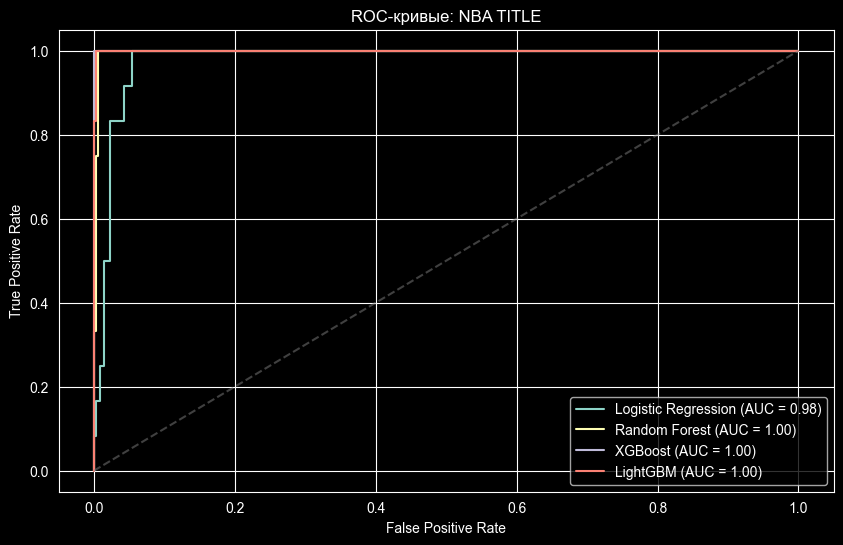


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,0.9995,0.9917,0.0418,0.0094,0.8000
2,XGBoost,1.0000,0.9861,0.0443,0.0111,0.7059
1,Random Forest,0.9974,0.9750,0.0519,0.0154,0.5714
0,Logistic Regression,0.9796,0.9278,0.1934,0.0548,0.3158



Анализ важности признаков для лучшей модели (LightGBM):
   Feature  Importance
         W 5062.353877
    FG_PCT 1120.064078
PLUS_MINUS  342.151391
       AST  324.743592
       BLK  243.867138
      FG3A  185.084288
       FGM  166.022056
   FG3_PCT  119.312898
       REB  117.607295
      DREB  114.580507


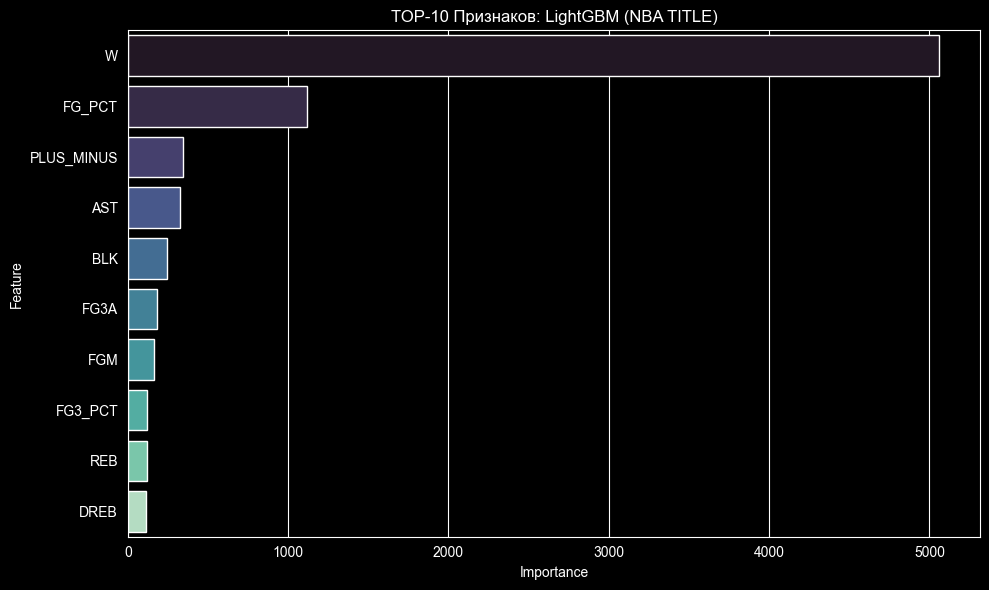

In [10]:
final_nba_title_model = train_and_evaluate(df_teams, 'IS_CHAMPION', team_features, "NBA TITLE")

### Шаг 5: Прогнозирование MVP (Most Valuable Player)

Огромный отрыв за параметром NBA_FANTASY_PTS, который является комбинацией всех основных стат, и что интересно 2-ой по важности показатель - это REB
  (в последние годы награду mvp брали в основном большие игроки и модель это заметила)


Здесь я отсекаю игроков, которые сыграли в серднем меньше 15 минут и в общем меньше 50 игр, эти игоки просто из правил регламента не могут заслужить награду

ЗАДАЧА: MVP (Most Valuable Player)


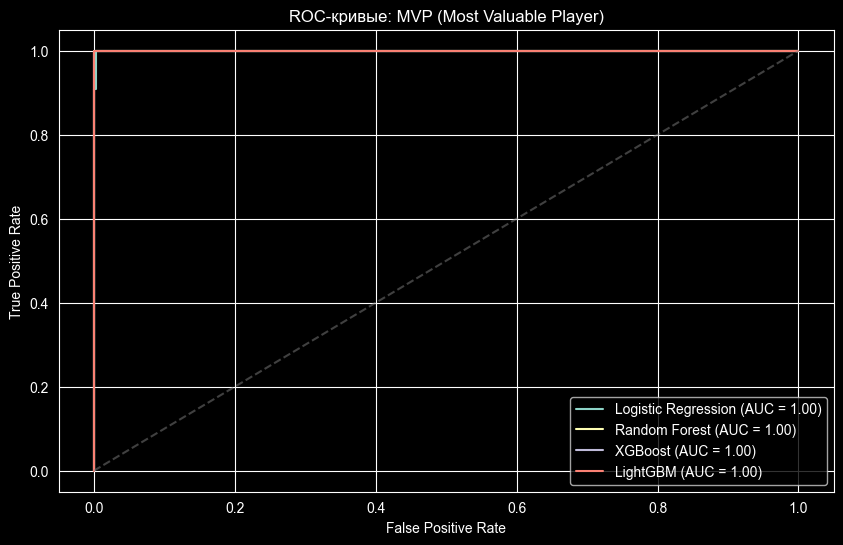


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0001,0.0000,1.0000
1,Random Forest,1.0000,0.9997,0.0051,0.0013,0.9167
2,XGBoost,1.0000,0.9997,0.0054,0.0005,0.9167
0,Logistic Regression,0.9994,0.9923,0.0220,0.0061,0.3143



Анализ важности признаков для лучшей модели (LightGBM):
        Feature    Importance
NBA_FANTASY_PTS 424030.179402
            REB  50389.358657
              W   4837.078927
            PTS   2632.303988
     PLUS_MINUS   1746.149976
         FG_PCT   1337.416771
            TOV   1140.940989
            AST    314.006815
            MIN    296.367893
        FG3_PCT    158.094369


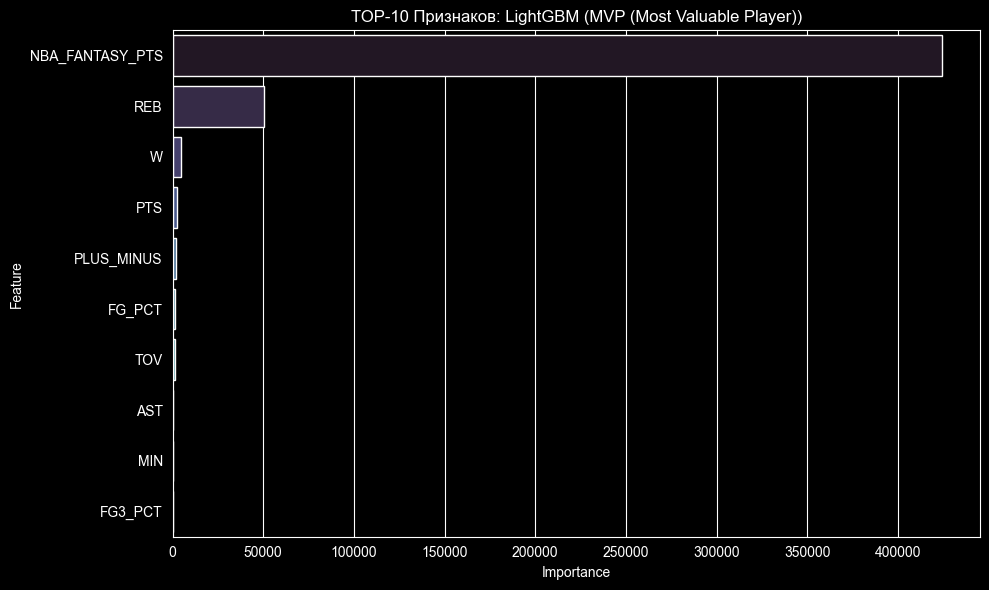

In [11]:
df_mvp = df_players[df_players['MIN'] > 15].copy()
df_mvp = df_mvp[df_mvp['GP'] > 50].copy()
final_mvp_model = train_and_evaluate(df_mvp, 'IS_MVP', players_features, "MVP (Most Valuable Player)")

### Шаг 6: Прогнозирование DPOY (Defensive Player of the Year)

Большой отрыв за параметром PLUS_MINUS, который показывает разницу очков с игроком на площадке, 2-м показателям стал PFD(количество фолов заработанных на игроке)


Здесь я также отсекаю игроков, которые сыграли в серднем меньше 15 минут и в общем меньше 50 игр, эти игоки просто из правил регламента не могут заслужить награду

ЗАДАЧА: DPOY (Defensive Player of the Year)


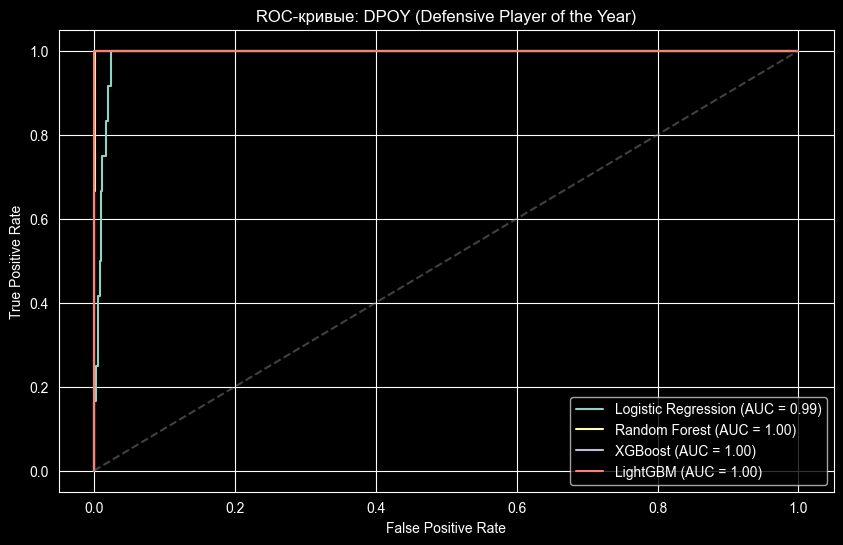


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
3,LightGBM,1.0000,1.0000,0.0002,0.0000,1.0000
2,XGBoost,1.0000,0.9984,0.0087,0.0013,0.7059
1,Random Forest,0.9995,0.9971,0.0176,0.0040,0.5714
0,Logistic Regression,0.9902,0.9610,0.1296,0.0315,0.0902



Анализ важности признаков для лучшей модели (LightGBM):
   Feature    Importance
PLUS_MINUS 276861.291628
       PFD  68316.146449
  STL_RANK  23135.823965
  BLK_RANK  12989.741635
       BLK   7511.664787
       MIN   1811.604273
       REB    897.769306
      OREB    698.697549
       STL    505.920098
       TOV    383.876200


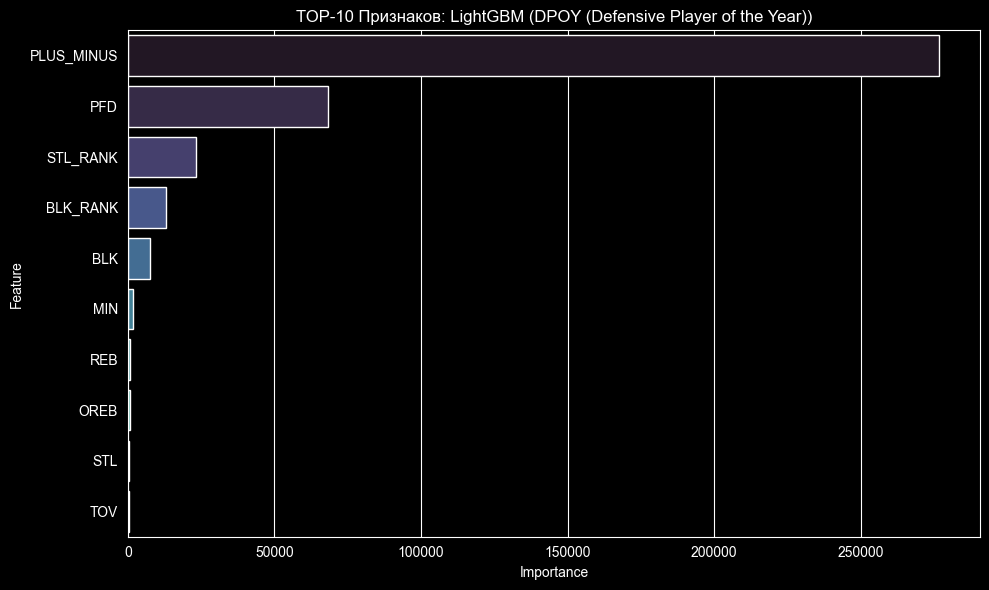

In [12]:
df_dpoy = df_players[df_players['MIN'] > 15].copy()
df_dpoy = df_dpoy[df_dpoy['GP'] > 50].copy()
final_dpoy_model = train_and_evaluate(df_dpoy, 'IS_DPOY', dpoy_features, "DPOY (Defensive Player of the Year)")

### Шаг 7: Прогнозирование MIP (Most Improved Player)

В данной задаче Random Forest показала, что есть несколько важных параметров для предсказания награды

Здесь я также отсекаю игроков, которые сыграли в серднем меньше 10 минут за игру

ЗАДАЧА: MIP (Most Improved Player)


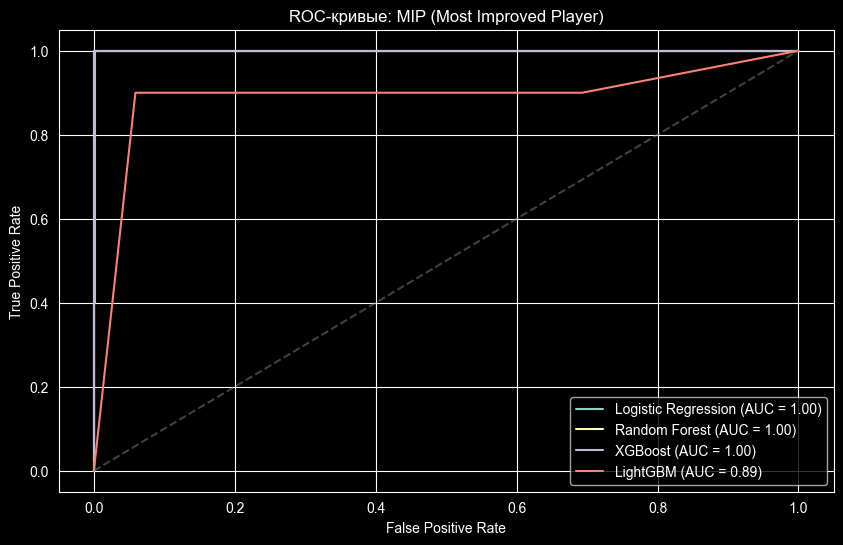


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
1,Random Forest,1.0000,0.9994,0.0059,0.0011,0.7692
2,XGBoost,1.0000,0.9971,0.0099,0.0019,0.4000
0,Logistic Regression,0.9990,0.9899,0.0275,0.0071,0.1613
3,LightGBM,0.8888,0.9410,2.1281,0.0590,0.0288



Анализ важности признаков для лучшей модели (Random Forest):
              Feature  Importance
DELTA_NBA_FANTASY_PTS    0.222941
                  MIN    0.194442
            DELTA_PTS    0.160457
      NBA_FANTASY_PTS    0.090073
             PTS_RANK    0.059292
                  FGA    0.051963
                  TOV    0.051061
            DELTA_AST    0.040974
                  AST    0.028697
                  PTS    0.018868


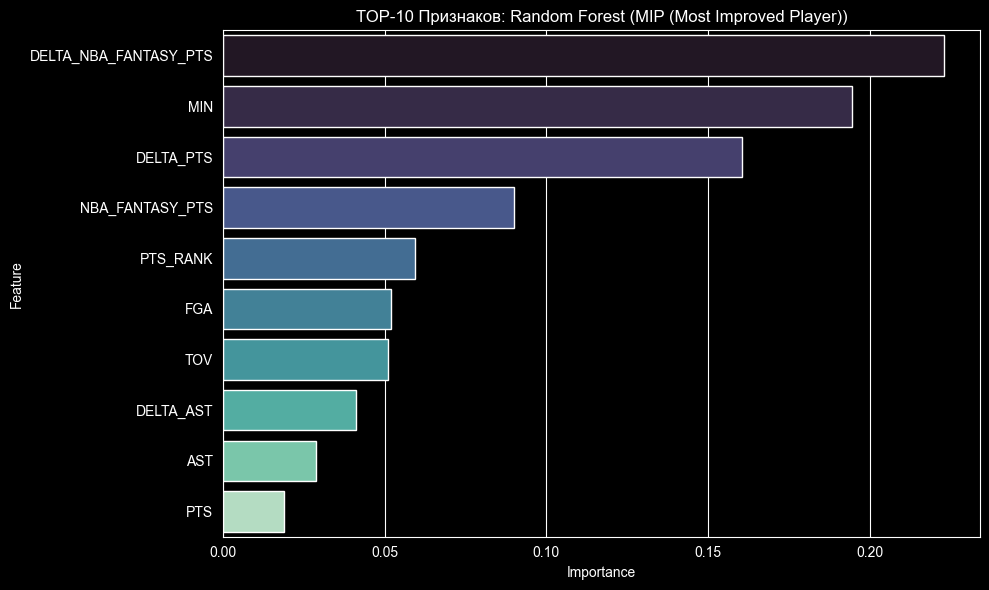

In [13]:
df_mip = df_players[df_players['MIN'] > 10].copy()
final_mip_model = train_and_evaluate(df_mip, 'IS_MIP', mip_features, "MIP (Most Improved Player)")

Я попробовал переобучить модель на этих параметрах и в среднем LogLoss упал

ЗАДАЧА: new MIP (Most Improved Player)


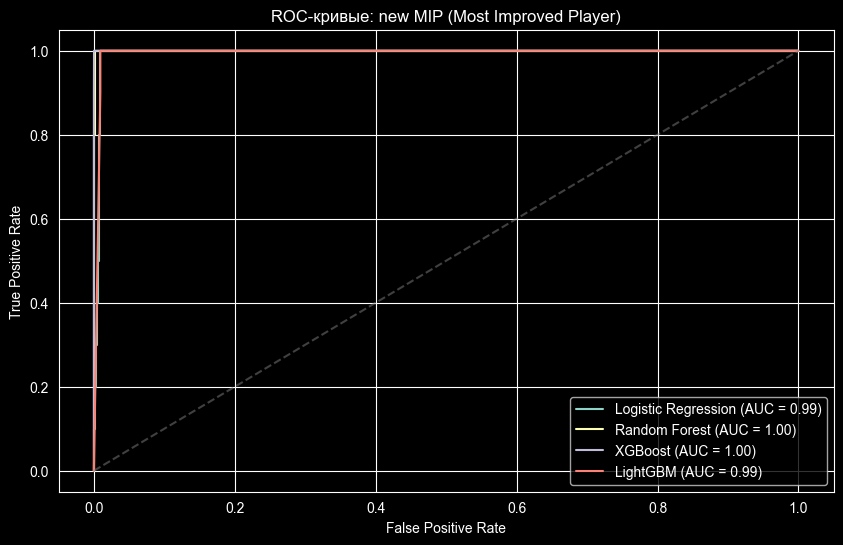


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
2,XGBoost,1.0000,0.9988,0.0071,0.0009,0.6250
1,Random Forest,0.9996,0.9984,0.0071,0.0017,0.5556
0,Logistic Regression,0.9946,0.9765,0.0793,0.0176,0.0763
3,LightGBM,0.9950,0.9909,0.3292,0.0091,0.1754



Анализ важности признаков для лучшей модели (XGBoost):
              Feature  Importance
DELTA_NBA_FANTASY_PTS    0.757070
                  MIN    0.130178
      NBA_FANTASY_PTS    0.049040
            DELTA_PTS    0.028763
                  FGA    0.011957
                  TOV    0.010436
                  AST    0.008595
             PTS_RANK    0.003961
            DELTA_AST    0.000000


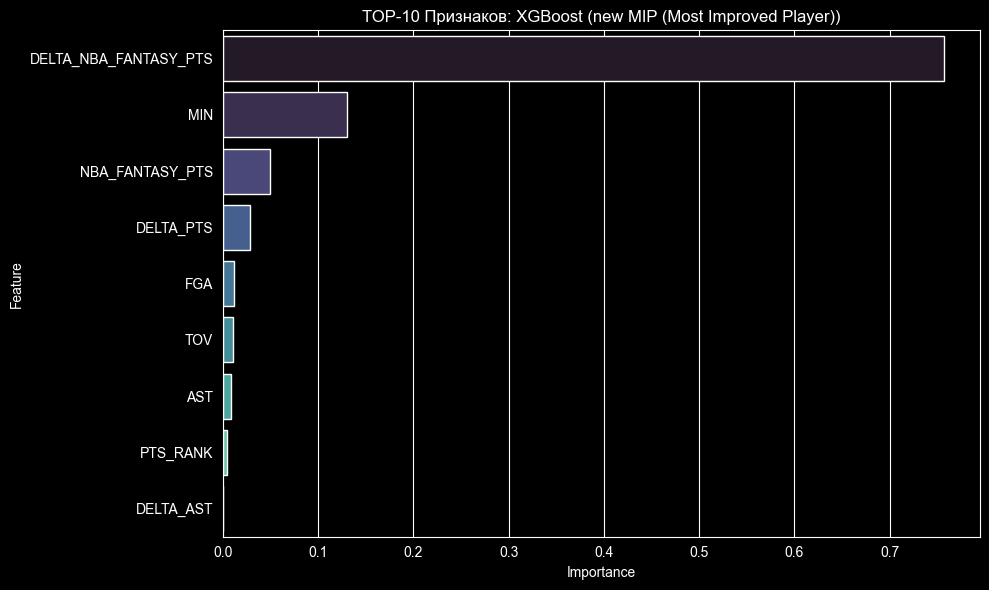

In [14]:
new_mip_features = ['DELTA_NBA_FANTASY_PTS', 'MIN', 'DELTA_PTS', 'NBA_FANTASY_PTS', 'PTS_RANK', 'FGA', 'TOV', 'DELTA_AST', 'AST']
final_mip_model = train_and_evaluate(df_mip, 'IS_MIP', new_mip_features, "new MIP (Most Improved Player)")

### Шаг 8: Прогнозирование ROTY (Rookie of the Year)

NBA_FANTASY_PTS опять стал самым важным параметром для предсказаниия

я выбирал только игроков, которые проводят первый сезон в лиге

ЗАДАЧА: ROTY (Rookie of the Year)


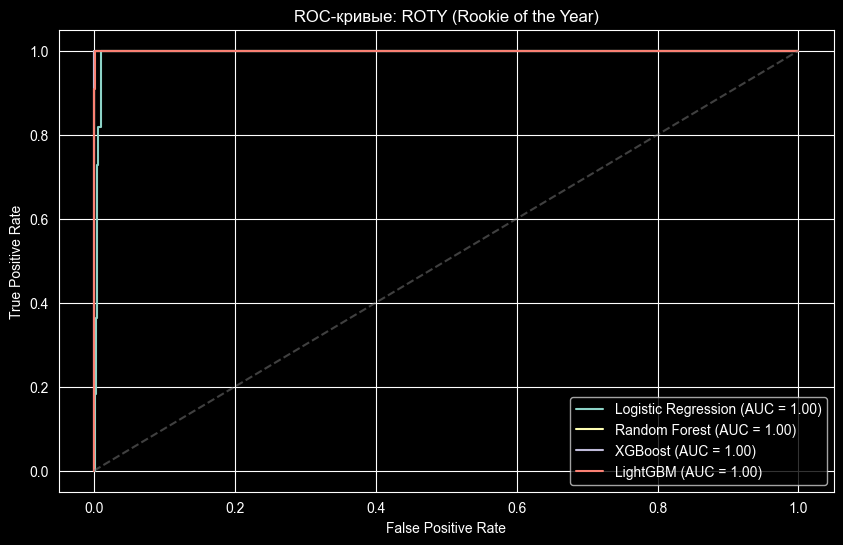


Итоговые метрики (Ранжирование по LogLoss):


,Модель,AUC,Accuracy,LogLoss,Brier,Precision
2,XGBoost,1.0000,0.9975,0.0096,0.0016,0.7333
1,Random Forest,0.9997,0.9994,0.0107,0.0027,0.9167
3,LightGBM,0.9999,0.9963,0.0141,0.0037,0.6471
0,Logistic Regression,0.9951,0.9769,0.0783,0.0182,0.2292



Анализ важности признаков для лучшей модели (XGBoost):
         Feature  Importance
 NBA_FANTASY_PTS    0.817561
             FGA    0.035785
             AST    0.029465
      W_PCT_RANK    0.013335
           W_PCT    0.011858
             MIN    0.011724
PLAYER_PTS_SHARE    0.011706
             TOV    0.009263
             REB    0.009255
        PTS_RANK    0.008830


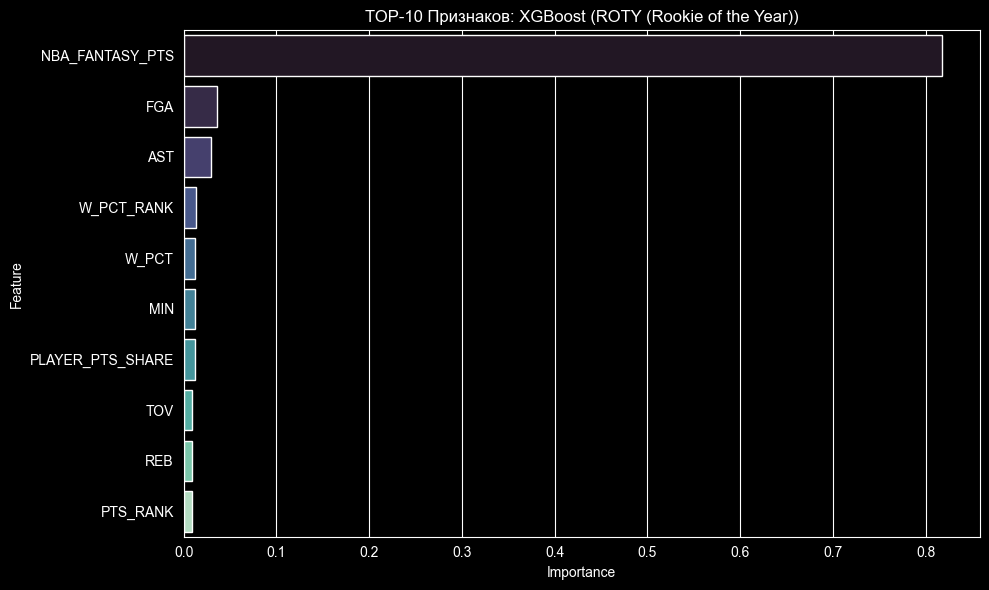

In [15]:
df_rookies = df_players[df_players['IS_ROOKIE_YEAR'] == 1].copy()
final_roty_model = train_and_evaluate(df_rookies, 'IS_ROY', players_features, "ROTY (Rookie of the Year)")

### Шаг 9: Вероятные победиетли по каждой из наград

Предсказания лучших моделей для кажной из наград:

ПРОГНОЗ: NBA Champion (Сезон 2025-26)


,TEAM_NAME,Шанс на победу (%)
556,Oklahoma City Thunder,24.870001
562,San Antonio Spurs,21.680000
544,Detroit Pistons,18.620001
555,New York Knicks,13.050000
549,Los Angeles Lakers,11.700000


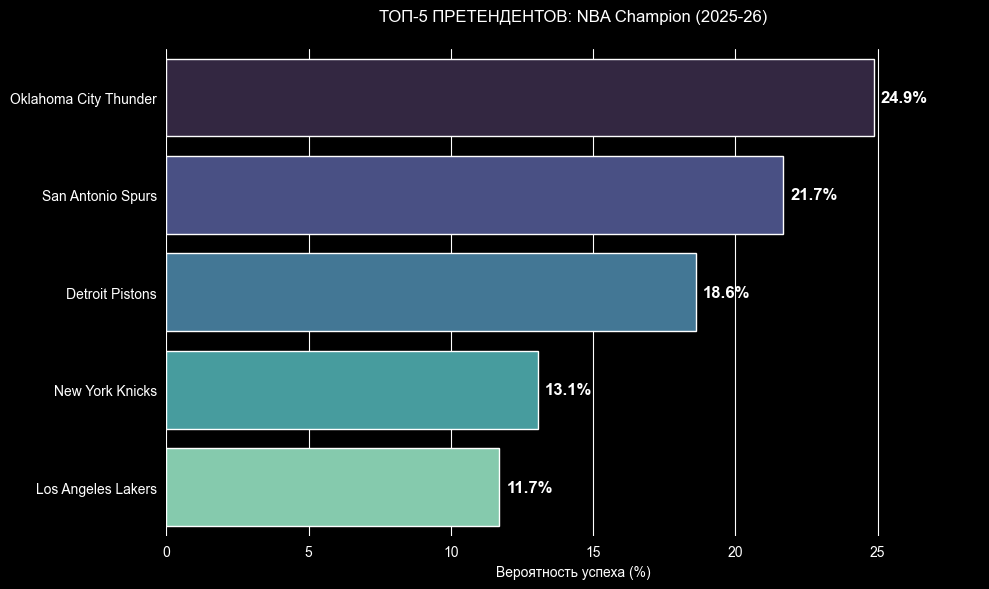


ПРОГНОЗ: MVP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
4648,Shai Gilgeous-Alexander,78.919998
3161,Nikola Jokić,45.049999
6542,Victor Wembanyama,13.320000
4876,Luka Dončić,8.270000
5594,Tyrese Maxey,0.990000


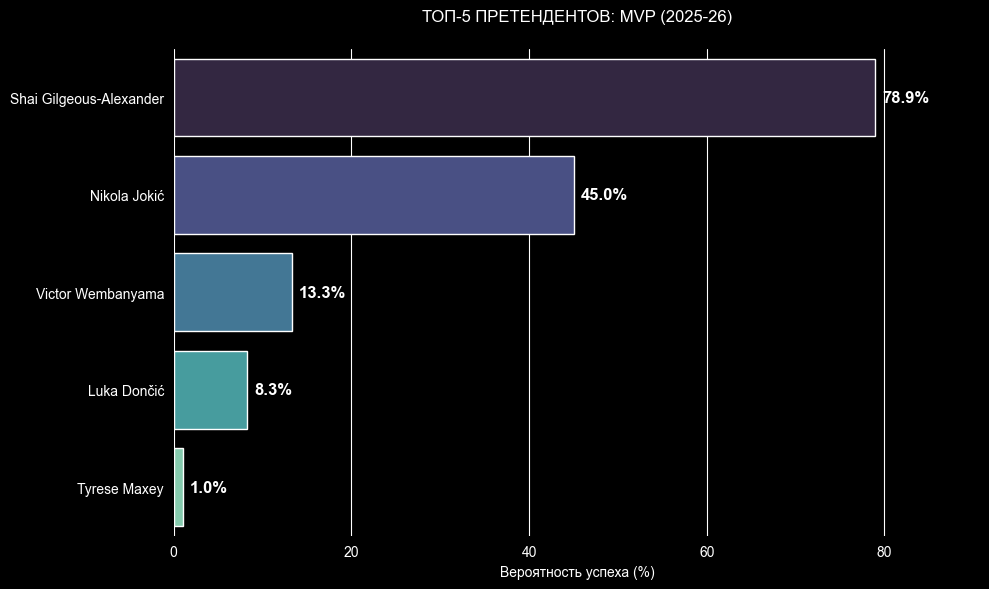


ПРОГНОЗ: DPOY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6542,Victor Wembanyama,73.779999
6258,Chet Holmgren,67.879997
6291,Jalen Duren,6.980000
2563,Rudy Gobert,4.430000
3335,Karl-Anthony Towns,2.550000


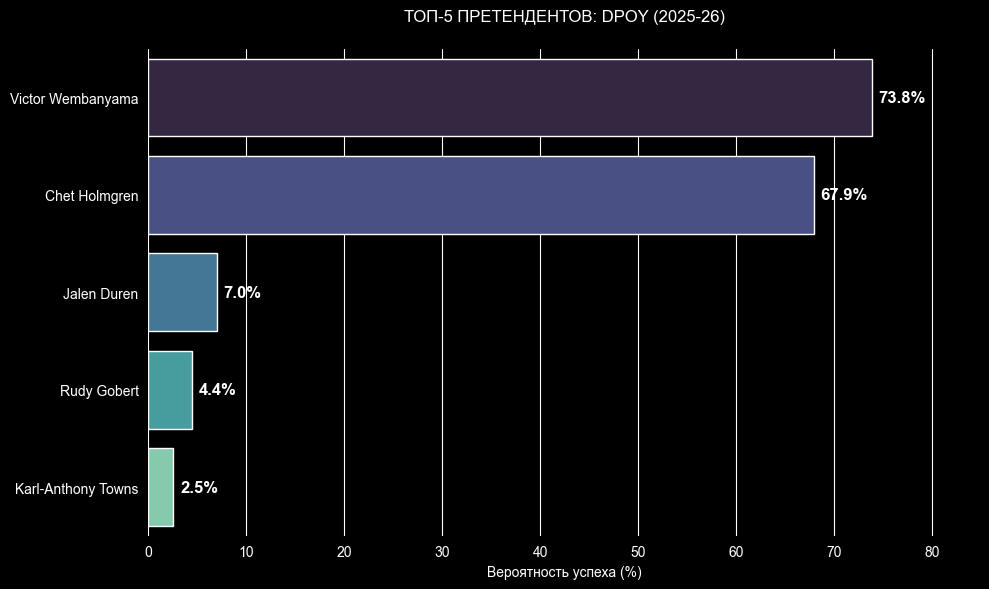


ПРОГНОЗ: MIP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
5200,Nickeil Alexander-Walker,72.41
5528,Deni Avdija,56.71
5238,Kevin Porter Jr.,27.85
4161,Lauri Markkanen,26.64
6375,Ryan Rollins,23.84


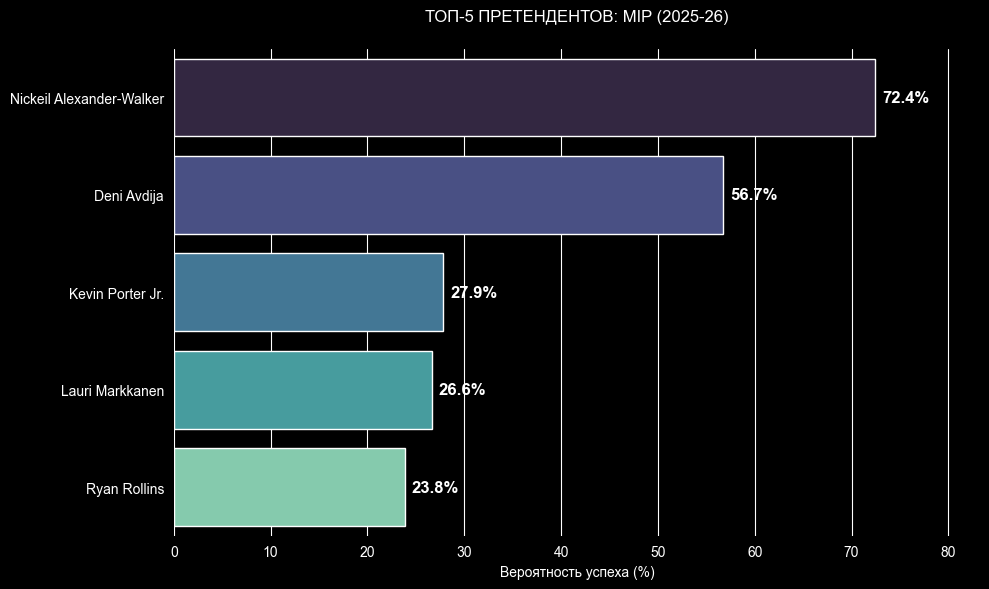


ПРОГНОЗ: ROTY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6870,Cooper Flagg,19.320000
6872,VJ Edgecombe,17.629999
6878,Derik Queen,3.370000
6871,Dylan Harper,1.290000
6874,Jeremiah Fears,1.190000


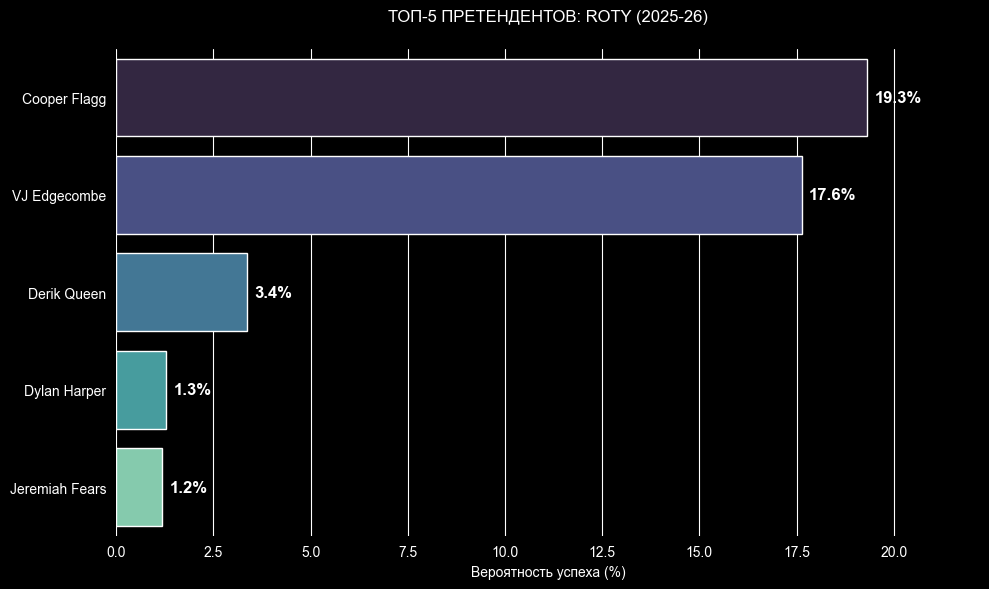


Предсказания, которые яв-ся самыми близкими к реальности по моему мнению:

ПРОГНОЗ: NBA Champion (Сезон 2025-26)


,TEAM_NAME,Шанс на победу (%)
556,Oklahoma City Thunder,72.57
544,Detroit Pistons,39.34
543,Denver Nuggets,36.50
562,San Antonio Spurs,34.10
555,New York Knicks,32.00


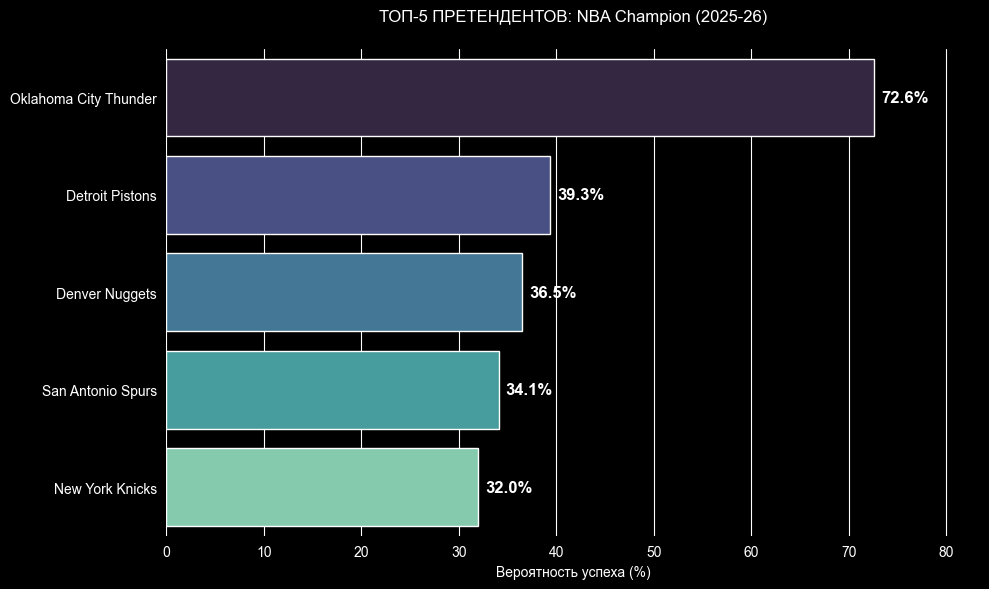


ПРОГНОЗ: MVP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
4648,Shai Gilgeous-Alexander,78.919998
3161,Nikola Jokić,45.049999
6542,Victor Wembanyama,13.320000
4876,Luka Dončić,8.270000
5594,Tyrese Maxey,0.990000


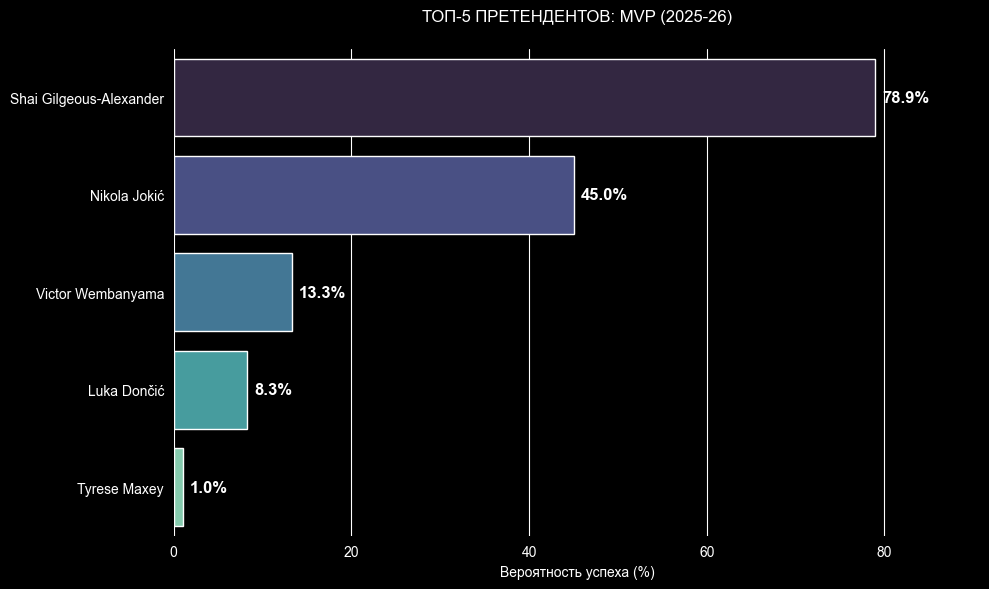


ПРОГНОЗ: DPOY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6542,Victor Wembanyama,73.75
6258,Chet Holmgren,66.91
6291,Jalen Duren,39.29
6114,Evan Mobley,33.38
3161,Nikola Jokić,28.40


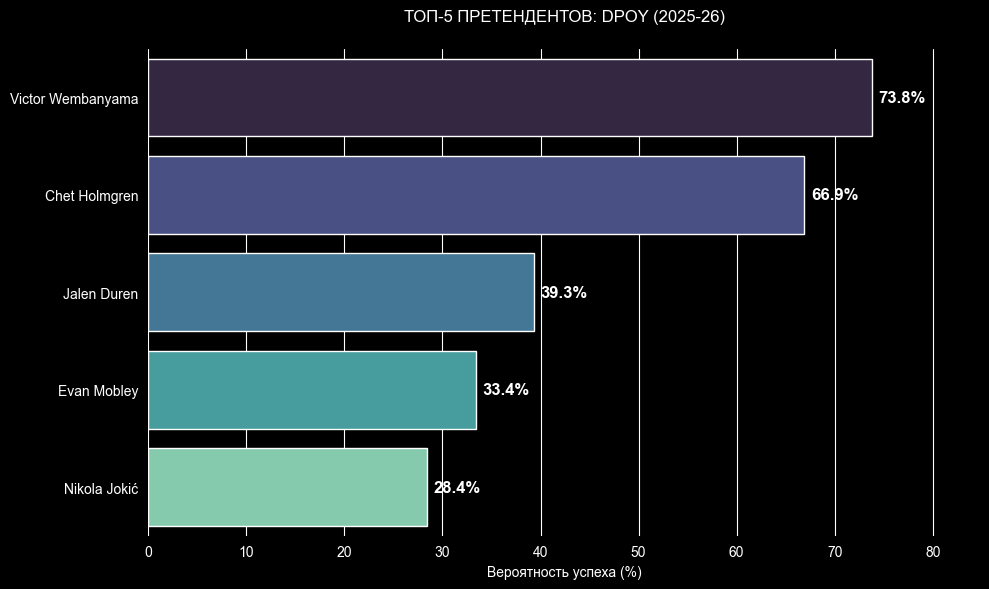


ПРОГНОЗ: MIP (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
5200,Nickeil Alexander-Walker,72.41
5528,Deni Avdija,56.71
5238,Kevin Porter Jr.,27.85
4161,Lauri Markkanen,26.64
6375,Ryan Rollins,23.84


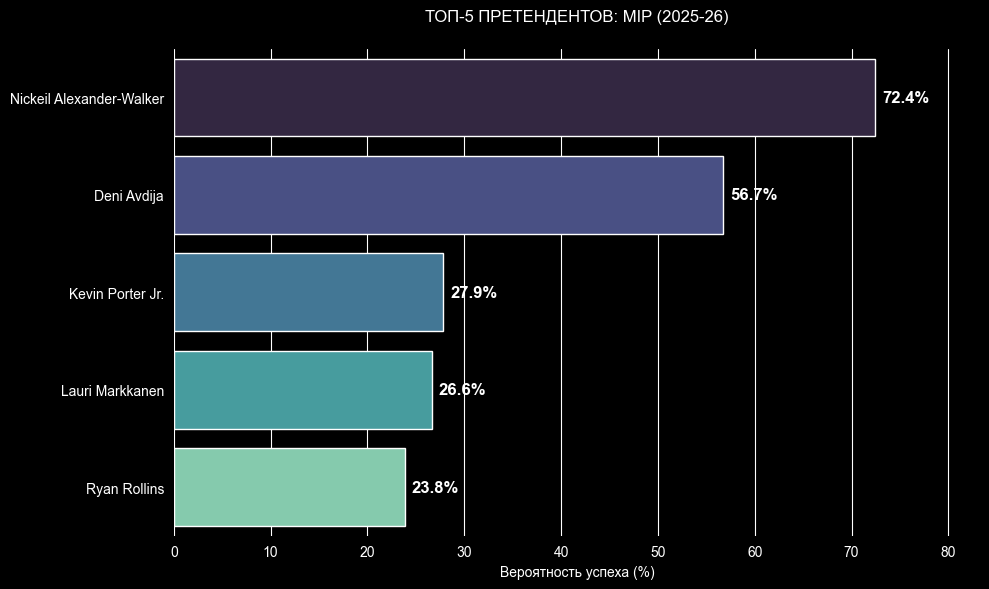


ПРОГНОЗ: ROTY (Сезон 2025-26)


,PLAYER_NAME,Шанс на победу (%)
6870,Cooper Flagg,19.320000
6872,VJ Edgecombe,17.629999
6878,Derik Queen,3.370000
6871,Dylan Harper,1.290000
6874,Jeremiah Fears,1.190000


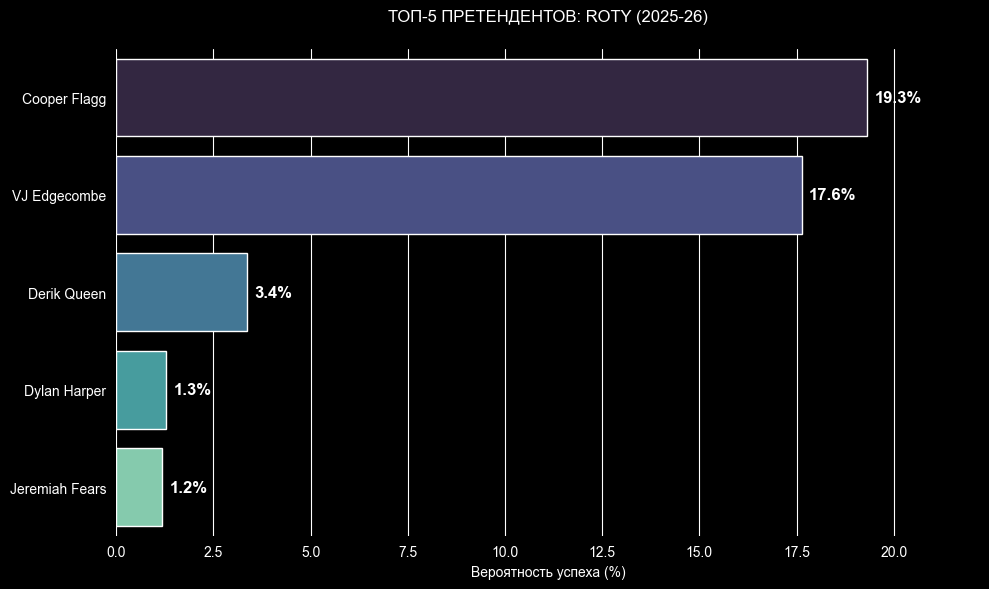

In [16]:
def predict_and_show_probabilities(df, target, features, entity_col, task_name, model):
    print(f"\nПРОГНОЗ: {task_name} (Сезон 2025-26)")

    train_df = df[df['SEASON'] < '2025-26'].dropna(subset=features + [target])
    future_df = df[df['SEASON'] == '2025-26'].dropna(subset=features).copy()

    if future_df.empty:
        print(f"Нет данных для прогноза {task_name} на сезон 2025-26.")
        return

    X_train = train_df[features]
    y_train = train_df[target]
    X_future = future_df[features]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
    X_future_scaled = pd.DataFrame(scaler.transform(X_future), columns=features)

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_future_scaled)[:, 1]
    future_df['Шанс на победу (%)'] = (probs * 100).round(2)

    top_candidates = future_df.sort_values('Шанс на победу (%)', ascending=False).head(5)
    display(top_candidates[[entity_col, 'Шанс на победу (%)']])

    ax = sns.barplot(
        data=top_candidates,
        x='Шанс на победу (%)',
        y=entity_col,
        palette='mako',
        hue=entity_col,
        legend=False
    )
    for i in ax.containers:
        ax.bar_label(i, padding=5, fmt='%.1f%%', fontsize=12, fontweight='bold')
    plt.title(f'ТОП-5 ПРЕТЕНДЕНТОВ: {task_name} (2025-26)', pad=20)
    plt.xlabel('Вероятность успеха (%)')
    plt.ylabel('')
    plt.xlim(0, max(top_candidates['Шанс на победу (%)']) * 1.15)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()


print("Предсказания лучших моделей для кажной из наград:")
predict_and_show_probabilities(df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

predict_and_show_probabilities(df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

predict_and_show_probabilities(df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

predict_and_show_probabilities(df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))



print(f"\nПредсказания, которые яв-ся самыми близкими к реальности по моему мнению:")

predict_and_show_probabilities(df_teams, 'IS_CHAMPION', team_features, 'TEAM_NAME', 'NBA Champion',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_mvp, 'IS_MVP', players_features, 'PLAYER_NAME', 'MVP',
     XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

predict_and_show_probabilities(df_dpoy, 'IS_DPOY', dpoy_features, 'PLAYER_NAME', 'DPOY',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_mip, 'IS_MIP', mip_features, 'PLAYER_NAME', 'MIP',
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42))

predict_and_show_probabilities(df_rookies, 'IS_ROY', players_features, 'PLAYER_NAME', 'ROTY',
    XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, eval_metric='logloss'))

